# 📜 Proyecto final - Machine Learning #
#### 🖊️ Grupo 2 - Ineta Keryte, Anthonny Maldonado, Guillermo Mansanta ####

Este es el proyecto final de nuestro bootcamp de Machine Learning, donde demostramos las habilidades y conocimientos adquiridos a lo largo de nuestros estudios. A lo largo de este bootcamp, hemos estudiado diferentes modelos basados en proyectos de diferentes áreas y tipos. Ahora es el momento de crear nuestro propio proyecto utilizando el algoritmo que creemos que se adapta mejor a nuestro problema.

In [132]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
import streamlit as st
import pickle
import re
import json
import unicodedata

### 👩‍⚕️ Nuestro problema a resolver 👨🏻‍⚕️ ###

<p style="text-align: justify;">
En el contexto macroeconómico argentino, atravesado por inflación, inestabilidad en los precios y restricciones en el acceso al financiamiento, la gestión de inventarios se convierte en un factor crítico para la sostenibilidad de cualquier farmacia. La falta de una planificación de stock basada en criterios técnicos y analíticos impacta directamente tanto en la rentabilidad del negocio como en la calidad del servicio prestado a la comunidad.

Desde la perspectiva comercial, una mala política de inventarios genera una utilización ineficiente del capital de trabajo, con recursos financieros inmovilizados en mercadería de baja rotación o con riesgo de vencimiento. Esto incrementa los costos operativos, deteriora el flujo de caja y limita la capacidad de negociación con droguerías y laboratorios, afectando condiciones de pago, descuentos y líneas de crédito.

Desde la perspectiva del servicio farmacéutico, los errores de planificación derivan en quiebres de stock de medicamentos esenciales, demoras en la atención, pérdida de continuidad en tratamientos y disminución de la confianza de los pacientes y clientes. La farmacia deja de ser percibida como un punto de referencia sanitario confiable y pasa a ser vista como un comercio reactivo e ineficiente.

En conjunto, la ausencia de una gestión profesional del inventario compromete simultáneamente la competitividad económica del negocio y su rol social como prestador de un servicio de salud.

👉 ## Problema real: la farmacia no cuenta con una metodología objetiva para anticipar la demanda futura de sus productos.
</p>


### 🎯 Objetivo de nuestro proyecto ### 

<p style="text-align: justify;">
Este proyecto tiene como objetivo aplicar técnicas de Machine Learning para mejorar la forma en que una farmacia gestiona su stock. A partir del análisis de las ventas de un año completo (2025) de una farmacia ubicada en la provincia de Buenos Aires, se busca entender cómo se comporta la demanda de los productos y usar esa información para planificar mejor el inventario del año 2026. La idea principal es pasar de una gestión basada solo en la experiencia a una gestión basada en datos, que permita anticiparse a las necesidades de los clientes, evitar faltantes de productos importantes y reducir el exceso de mercadería en un contexto económico cambiante. Todo el enfoque está pensado desde la realidad del negocio farmacéutico y el comportamiento de consumo de las personas.
</p>

### Dataset - Carga de conjunto de datos 💊

In [133]:
df = pd.read_csv("../data/raw/farmacia-datos.csv", sep=";", encoding="latin1")
df.head()

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


<p style="text-align: justify;">
El dataset contiene información de registro de ventas durante el año 2025 de una farmacia situada en Argentina, en la provincia de Buenos Aires. El registro se corresponde a los datos de los tickets de venta generados durante todo el año, los días que el comercio estuvo abierto. Teniendo en cuenta que el comercio trabaja de Lunes a Sábados de 8hs a 20 hs, es decir, 12 hs por día, se han generado un total de datos tal que nuestro dataset contiene:
</p>

- 117.415 filas

- 20 columnas, con variables categoricas y numericas como: ['Fecha', 'Tipo Mov.', 'Fac. Tipo', 'Fac. Suc.', 'Fac. Nun.','Fisc. Numero', 'Tipo Pago', 'Cant.', 'Precio', 'Producto', 'Sub. Total', 'Rubro', 'Cobertura', 'Ajustes', 'Desc. Adic.', 'Total. Cliente', 'IVA', 'Tasa Iva', 'Total Gravado', 'Total sin Gravar']

- Más de 7.500 productos distintos

- Rubro farmacia (medicamentos, insumos médicos, suplementos, vitaminas, salud preventiva) y perfumería y cuidado personal (cremas, protectores, higiene).
<p style="text-align: justify;">
Se trata de un conjunto de datos reales, lo que implica la presencia de ruido, valores inconsistentes, formatos heterogéneos y registros incompletos, características habituales en fuentes operativas del sector farmacéutico. Esta naturaleza del dataset representó un desafío significativo durante la etapa de data cleaning, ya que fue necesario aplicar múltiples técnicas de depuración, normalización y validación para garantizar la calidad de los datos antes de avanzar con el análisis y el modelado.
</p>

In [134]:
df.shape

(117415, 20)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  object 
 15  Total. Cliente    117415 non-null  object 
 16  IVA               11

In [136]:
df.duplicated().sum()

np.int64(121)

In [137]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.duplicated().sum()

np.int64(0)

### Observaciones

 - Se logran visualizar los datos, en cada fila podemos darnos cuenta que es una venta. Alguna de ellas comparten el mismo numero de ticket, lo cual no da a entender que hay varios articulos dentro de un mismo ticket.
 - Encontramos unos duplicados pero para descartarlas tomamos la decision de evaluarlas antes para tener una decision mas acertada. Tenemos 20 columnas y estudiaremos cada una de ellas.
 - Prodecimos a eliminar la columna `Fisc. Numero` dado que no tiene ningun valor en ninguna fila.

In [138]:
df.drop(["Fisc. Numero"],axis=1, inplace=True)

### Almacenamiento de información

In [139]:
df.columns = df.columns.str.replace('.', '', regex=False).str.replace(' ', '_')

Para la ejecución de las consultas SQL se normalizaron los nombres de columnas para garantizar la correcta agregación de variables numéricas.

In [140]:
# Create connection to SQLite
conn = sqlite3.connect('farmacia-datos.db')

In [141]:
# Save table
df.to_sql('ventas', conn, if_exists='replace', index=False)

117294

In [142]:
# Verify that the table exists
query = 'SELECT * FROM ventas LIMIT 5;'
pd.read_sql(query, conn)

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,01/01/25 01.13.46,F,B,0,379923,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


### Top 10 productos mas vendidos.

In [143]:
# Execute a real SQL query
query_top_10 = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto
ORDER BY Demanda_total DESC
LIMIT 10;
'''
pd.read_sql(query_top_10, conn)

,Producto,Demanda_total
0,BUSCAPINA COMPOSITUM comp.rec.x 20,2648
1,QURA PLUS comp.rec.x 20,2601
2,GEN LP IBUPROFENO blister 600 mg x 10,2134
3,SERTAL COMPUESTO comp.rec.x 20,1786
4,GEN LP OMEPRAZOL blister 20 mg x 15,1574
5,ALIKAL (unica),1483
6,MYLANTA EXTRA comp.mast.x 24,1270
7,ASPIRINA PREVENT comp.cub.enterica x 50,1159
8,CAFIASPIRINA comp.x 30,1040
9,TAFIROL 1G X 8 (unica),983


> - Se almacenaron los datos en una base de datos SQLite y se realizaron consultas SQL desde Python para identificar productos de alta rotación y patrones de demanda.

#### Demanda total por producto

In [144]:
query_product = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto;
'''
pd.read_sql(query_product, conn)

,Producto,Demanda_total
0,None,1
1,CHUP.MANZANITA(C/DIBUJO)T/SILIC.+3M RED - ES...,1
2,(unica),4
3,1,1
4,1 1,7
...,...,...
7671,q,1
7672,|,1
7673,º,3
7674,ÓLEO Calcáreo x 240 ml.,1


> - Esta consulta permite identificar los productos con mayor volumen de ventas acumuladas, fundamentales para la gestión de stock y la priorización de reposición.

In [145]:
query_coverage = """
SELECT Cobertura, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Cobertura;
"""
pd.read_sql(query_coverage, conn)


,Cobertura,Demanda_total
0,"-157953,92",1
1,0,107039
2,10000,1
3,"10000,188",1
4,"10001,04",3
...,...,...
23016,"9993,308",1
23017,"9995,3",3
23018,"9998,392",2
23019,"9998,952",1


> - La presencia de cobertura médica incrementa la demanda, lo cual debe considerarse en la planificación de inventario.

## Análisis descriptivo de las variables

Variable clave: `Cant`

In [146]:
df['Cant'].describe()

count    117294.000000
mean          1.368314
std           1.862667
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         106.000000
Name: Cant, dtype: float64

In [147]:
average = df['Cant'].mean()
median = df['Cant'].median()
mode = df['Cant'].mode()[0]
variance = df['Cant'].var()
skewness = df['Cant'].skew()

In [148]:
print(f'Media:     {average:.2f}')
print(f'Mediana:   {median:.2f}')
print(f'Moda:      {mode:.2f}')
print(f'Varianza:  {variance:.2f}')
print(f'Asimetría: {skewness:.2f}')

Media:     1.37
Mediana:   1.00
Moda:      1.00
Varianza:  3.47
Asimetría: 12.14


- **Media** (1.37) vs **Mediana** (1.00): El hecho de que la media sea mayor que la mediana indica que la distribución está sesgada a la derecha. Mientras que la mayoría de los clientes compran solo 1 unidad (mediana), hay un grupo pequeño de transacciones con cantidades muy altas que elevan el promedio.
- **Moda** (1.00): Es el valor más frecuente. Esto confirma que el comportamiento estándar en la farmacia es la compra de una única unidad por producto (típico de medicamentos bajo receta).
- **Varianza** (3.47): La desviación estándar sería la raíz cuadrada de esto (≈1.86). Aunque la mayoría compra 1 unidad, hay una variabilidad considerable. En términos de negocio, esto sugiere que conviven dos tipos de clientes: el consumidor final (compra 1 unidad) y posiblemente clientes institucionales o crónicos (compran varias cajas o tratamientos completos).
- **Asimetría Positiva Extrema**: Un valor de 12.14 es extremadamente alto (en una distribución normal sería 0).   

Debido a esta asimetría, será necesario decidir si se eliminan esos valores extremos para entrenar el modelo de Machine Learning o si se tratan de forma especial, ya que podrían distorsionar las predicciones.

In [149]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fac_Suc,117294.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
Fac_Nun,117294.0,417631.799342,22418.434407,379923.0,398025.25,416261.0,437601.0,455865.0
Cant,117294.0,1.368314,1.862667,0.0,1.00,1.0,1.0,106.0
Ajustes,117294.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
Tasa_Iva,117294.0,4.085631,8.313029,0.0,0.00,0.0,0.0,21.0


In [150]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%y %H.%M.%S')

### Limpieza de datos: eliminación de información que detectamos que hace más ruido de lo que nos sirve.

In [151]:
products_no_name = df[df['Producto'].str.len() <= 4]['Producto'].unique()
products_no_name

array(['1 1', 'A1 1', '5200', 'º', '|', 'LIMA', 'q', '1'], dtype=object)

In [152]:
df = df[df['Producto'].str.len() > 4]

> - Se eliminaron registros cuyos nombres de producto tenían una longitud menor o igual a cuatro caracteres, ya que correspondían a valores erróneos o incompletos que no aportaban información relevante al análisis.

In [153]:
(df['Fac_Suc'] == 0).sum()

np.int64(117277)

In [154]:
df['Tipo_Mov'].unique()

array(['F'], dtype=object)

In [155]:
df['Fac_Tipo'].value_counts(dropna=False)

Fac_Tipo
B    117114
A       163
Name: count, dtype: int64

In [156]:
df['IVA'].value_counts(dropna=False)

IVA
0              94465
173,553719       982
520,661157       673
867,768595       658
780,9917355      641
               ...  
1818,81            1
2965,42562         1
3529,132959        1
1662,644628        1
4252,447517        1
Name: count, Length: 4217, dtype: int64

In [157]:
df['Tasa_Iva'].value_counts(dropna=False)

Tasa_Iva
0     94465
21    22812
Name: count, dtype: int64

In [158]:
df['Tipo_Pago'].value_counts(dropna=False)

Tipo_Pago
E    117277
Name: count, dtype: int64

In [159]:
df['Ajustes'].value_counts(dropna=False)

Ajustes
0    117277
Name: count, dtype: int64

In [160]:
df['Desc_Adic'].value_counts(dropna=False)

Desc_Adic
0             115135
-3,64E-12        226
-1,82E-12         86
-7,28E-12         79
-9,09E-13         24
               ...  
1450               1
8741,37096         1
4704,488           1
231,56             1
1148               1
Name: count, Length: 1155, dtype: int64

In [161]:
df["Producto"].value_counts()

Producto
GEN LP IBUPROFENO blister 600 mg x 10      1925
GEN LP OMEPRAZOL blister 20 mg x 15        1203
ASPIRINA PREVENT comp.cub.enterica x 50    1149
TAFIROL 1G X 8 (unica)                      870
TAFIROL 1 G comp.ran.x 50                   699
                                           ... 
TOBILLERA (unica)                             1
MECANYL DUO cáps.x 60                         1
FLEVOMAX 1000 mg comp.rec.x 30                1
ACCESORIOS LUCIA (unica)                      1
LRP ANTHELIOS XL SPF 50 FLU CO                1
Name: count, Length: 7667, dtype: int64

In [162]:
df["Rubro"].value_counts()

Rubro
FARMACIA           108266
PERFUMERIA           8910
NO ESPECIFICADO       101
Name: count, dtype: int64

In [163]:
df["Total_Gravado"].value_counts()

Total_Gravado
0              94465
826,446281       982
2479,338843      673
4132,231405      658
3719,008264      641
               ...  
8661               1
14121,07438        1
16805,39504        1
7917,355372        1
20249,75008        1
Name: count, Length: 4217, dtype: int64

In [164]:
df["Total_sin_Gravar"].value_counts()

Total_sin_Gravar
0           21995
3500         1410
5000         1376
4000         1316
3000          758
            ...  
9783            1
6942,08         1
26376,02        1
19010           1
9646,28         1
Name: count, Length: 26927, dtype: int64

In [165]:
df.columns

Index(['Fecha', 'Tipo_Mov', 'Fac_Tipo', 'Fac_Suc', 'Fac_Nun', 'Tipo_Pago',
       'Cant', 'Precio', 'Producto', 'Sub_Total', 'Rubro', 'Cobertura',
       'Ajustes', 'Desc_Adic', 'Total_Cliente', 'IVA', 'Tasa_Iva',
       'Total_Gravado', 'Total_sin_Gravar'],
      dtype='object')

In [166]:
df.dtypes

Fecha               datetime64[ns]
Tipo_Mov                    object
Fac_Tipo                    object
Fac_Suc                      int64
Fac_Nun                      int64
Tipo_Pago                   object
Cant                         int64
Precio                      object
Producto                    object
Sub_Total                   object
Rubro                       object
Cobertura                   object
Ajustes                      int64
Desc_Adic                   object
Total_Cliente               object
IVA                         object
Tasa_Iva                     int64
Total_Gravado               object
Total_sin_Gravar            object
dtype: object

#### Procederemos a ejecutar las siguientes acciones.

>1. Borraremos las variables `Tipo Mov.` y `Tipo Pago` por que todas las variables de cada columna tienen un valor unico que se repite. no aportaria nada realmente al Dataset y procederemos a borrarlo.
>2. Las variables `Precio`, `Sub. Total`, `Cobertura`, `Desc. Adic.`, `Total. Cliente`, `IVA`, `Total Gravado`, `Total sin Gravar` notamos que son variables numericas. las cambiaremos a flotantes para poder trabajarlas como variables numericas. 

In [167]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Tipo_Mov',
 'Fac_Tipo',
 'Tipo_Pago',
 'Precio',
 'Producto',
 'Sub_Total',
 'Rubro',
 'Cobertura',
 'Desc_Adic',
 'Total_Cliente',
 'IVA',
 'Total_Gravado',
 'Total_sin_Gravar']

In [168]:
df.drop(['Fac_Suc', 'Ajustes'], axis=1, inplace=True)

In [169]:
columns_to_numeric = ['Precio', 'Sub_Total', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA', 'Total_Gravado', 'Total_sin_Gravar']

for col in columns_to_numeric:
    df[col] = (df[col].astype(str).str.replace(',', '.').astype(float))

In [170]:
df.dtypes

Fecha               datetime64[ns]
Tipo_Mov                    object
Fac_Tipo                    object
Fac_Nun                      int64
Tipo_Pago                   object
Cant                         int64
Precio                     float64
Producto                    object
Sub_Total                  float64
Rubro                       object
Cobertura                  float64
Desc_Adic                  float64
Total_Cliente              float64
IVA                        float64
Tasa_Iva                     int64
Total_Gravado              float64
Total_sin_Gravar           float64
dtype: object

In [171]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Tipo_Mov', 'Fac_Tipo', 'Tipo_Pago', 'Producto', 'Rubro']

Las variables categóricas son: `Tipo_Mov`,`Fac_Tipo`,`Tipo_Pago`,`Producto`, `Rubro`.

In [172]:
final_categorical_variables = df.select_dtypes(include=['object'])
final_categorical_variables

,Tipo_Mov,Fac_Tipo,Tipo_Pago,Producto,Rubro
0,F,B,E,ACTRON PEDIATRICO 4% susp.oral x 100 ml,FARMACIA
1,F,B,E,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
2,F,B,E,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
3,F,B,E,MUELITA FORTE GEL gel pomo x 10 g,FARMACIA
4,F,B,E,DIOXAFLEX B12 comp.x 20,FARMACIA
...,...,...,...,...,...
117289,F,B,E,COLGATE (unica),FARMACIA
117290,F,B,E,TAFIROL 1 G comp.ran.x 50,FARMACIA
117291,F,B,E,CICATRICURE GEL Gel NF x 30 g,FARMACIA
117292,F,B,E,LOUTEN T colirio x 2.5 ml,FARMACIA


In [173]:
df[cat_variables].head()

,Tipo_Mov,Fac_Tipo,Tipo_Pago,Producto,Rubro
0,F,B,E,ACTRON PEDIATRICO 4% susp.oral x 100 ml,FARMACIA
1,F,B,E,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
2,F,B,E,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
3,F,B,E,MUELITA FORTE GEL gel pomo x 10 g,FARMACIA
4,F,B,E,DIOXAFLEX B12 comp.x 20,FARMACIA


#### Procederemos a ejecutar las siguientes acciones.

> - Borraremos las variables `Tipo Mov.` y `Tipo Pago` por que todas las variables de cada columna tienen un valor unico que se repite. no aportaria nada realmente al Dataset y procederemos a borrarlo.
> - Las variables `Precio`, `Sub. Total`, `Cobertura`, `Desc. Adic.`, `Total. Cliente`, `IVA`, `Total Gravado`, `Total sin Gravar` notamos que son variables numericas. las cambiaremos a flotantes para poder trabajarlas como variables numericas. 

In [174]:
df.drop(["Tipo_Mov", "Tipo_Pago"],axis=1, inplace=True)

In [175]:
df.dtypes

Fecha               datetime64[ns]
Fac_Tipo                    object
Fac_Nun                      int64
Cant                         int64
Precio                     float64
Producto                    object
Sub_Total                  float64
Rubro                       object
Cobertura                  float64
Desc_Adic                  float64
Total_Cliente              float64
IVA                        float64
Tasa_Iva                     int64
Total_Gravado              float64
Total_sin_Gravar           float64
dtype: object

In [176]:
fals_obj = ["Precio","Sub_Total","Cobertura","Desc_Adic","Total_Cliente","IVA","Total_Gravado","Total_sin_Gravar"]

df[fals_obj] = df[fals_obj].astype(str).apply(lambda col: col.str.replace(",", "."))
df[fals_obj] = df[fals_obj].apply(pd.to_numeric)

In [177]:
df[fals_obj]

,Precio,Sub_Total,Cobertura,Desc_Adic,Total_Cliente,IVA,Total_Gravado,Total_sin_Gravar
0,9344.00,9344.00,0.00,0.0,9344.00,0.000000,0.0000,9344.00
1,8174.96,8174.96,3032.85,0.0,5142.11,0.000000,0.0000,8174.96
2,8174.96,8174.96,5318.10,0.0,2856.86,0.000000,0.0000,8174.96
3,8086.82,8086.82,0.00,0.0,8086.82,0.000000,0.0000,8086.82
4,26750.12,26750.12,0.00,0.0,26750.12,0.000000,0.0000,26750.12
...,...,...,...,...,...,...,...,...
117289,5000.00,5000.00,0.00,0.0,5000.00,0.000000,0.0000,5000.00
117290,13641.20,13641.20,5808.98,0.0,7832.22,0.000000,0.0000,13641.20
117291,16000.00,16000.00,0.00,0.0,16000.00,2776.859504,13223.1405,0.00
117292,36758.39,36758.39,14703.36,0.0,22055.03,0.000000,0.0000,36758.39


In [178]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Fac_Tipo', 'Producto', 'Rubro']

> - Para un mejor estudio y un mejor análisis y posterior entrenamiento de modelo, dado que sólo hay registros de 12 meses, tomaremos un periodo de tiempo mas corto, para lo cual creamos una nueva columna con períodos temporales semanales.

In [179]:
df["num_semana"] = df["Fecha"].dt.isocalendar().week.astype(int)

In [180]:
df_copy = df.copy()

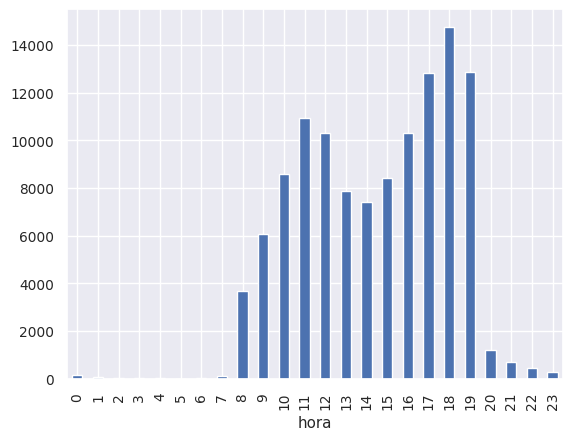

In [181]:
df_copy["hora"] = df_copy["Fecha"].dt.hour
df_copy["hora"].value_counts().sort_index().plot(kind="bar")
plt.show()

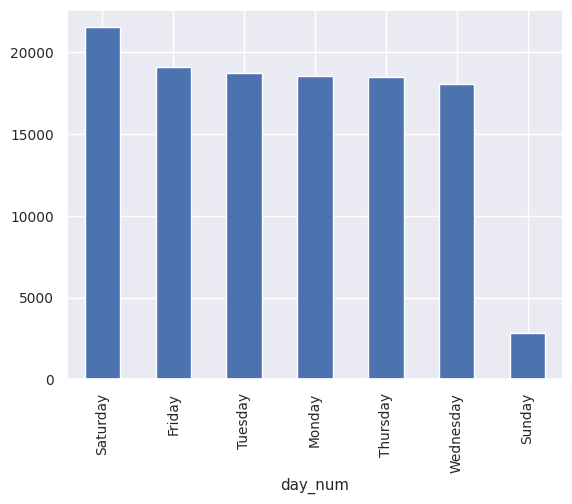

In [182]:
df_copy["day_num"] = df_copy["Fecha"].dt.day_name()
df_copy["day_num"].value_counts().plot(kind="bar")
plt.show()

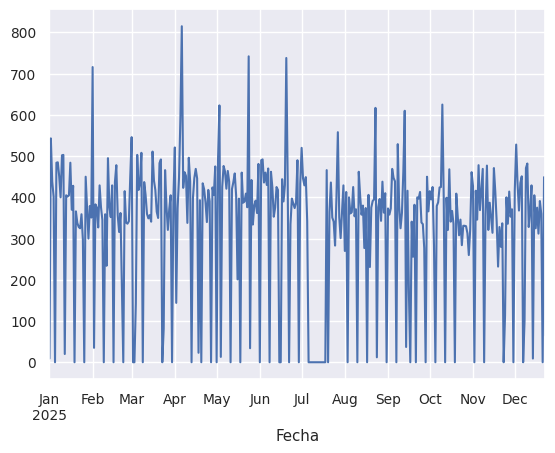

In [183]:
por_dia = df_copy.set_index("Fecha").resample("D").size()
por_dia.plot()
plt.show()

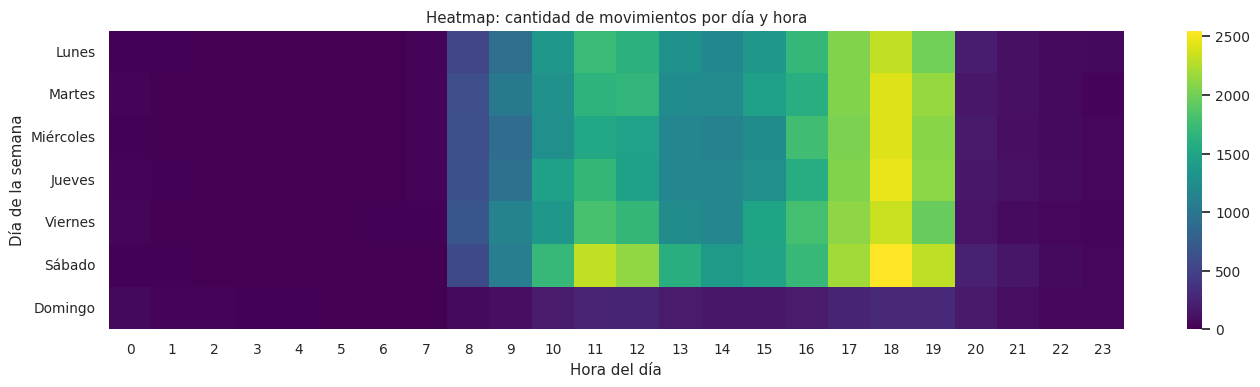

In [184]:
df_copy["day_num"] = df_copy["Fecha"].dt.dayofweek
df_copy["hour"] = df_copy["Fecha"].dt.hour
heat = pd.crosstab(df_copy["day_num"], df_copy["hour"])
heat = heat.reindex(index=range(7), columns=range(24), fill_value=0)
dias = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="viridis") 
plt.yticks(ticks=[i+0.5 for i in range(7)], labels=dias, rotation=0)
plt.xticks(rotation=0)
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Heatmap: cantidad de movimientos por día y hora")
plt.tight_layout()
plt.show()

In [185]:
cat_variables.remove("Producto")

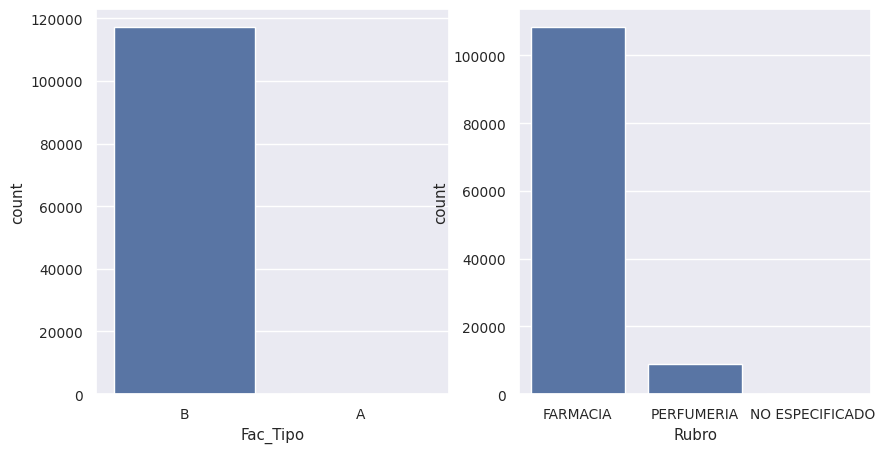

In [186]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))
sns.countplot(data=df, x=cat_variables[0], ax=axis[0])
sns.countplot(data=df, x=cat_variables[1], ax=axis[1])
plt.show()

### *Observaciones principales de los gráficos primeros:*

1. **Horas muertas en la madrugada**  
   Entre las 00:00 y las 07:00 prácticamente no hay movimientos. La farmacia presenta actividad casi nula en ese tramo horario, la mayor cantidad de días está cerrada de 20 hs a 8 am, pero hay días que le toca abrir y estar de turno/guardia zonal.

2. **Inicio fuerte de ventas desde la mañana**  
   A partir de las 08:00–09:00 las ventas aumentan notablemente y se mantienen altas durante el resto del día.

3. **Pico máximo al final de la tarde**  
   El mayor volumen de ventas se concentra alrededor de las 18:00–19:00, que puede considerarse el *prime time* del comercio.

4. **Caída brusca después de las 20:00**  
   Luego de las 20:00 se observa una disminución marcada en la cantidad de ventas. Es decir, la farmacia cierra a las 20 hs.

5. **El sábado es el día con más ventas**  
   El día sábado presenta el mayor volumen total de ventas de la semana.

6. **El domingo es el día más débil**  
   El domingo tiene un nivel de ventas muy inferior al resto, posiblemente por menor demanda u horario reducido. Al igual que las horas muertas, los días domingos la farmacia está cerrada al público, salvo excepciones que tenga que abrir por estar de turno/guardia zonal.

7. **Estabilidad entre martes y viernes**  
   Los días martes, miércoles, jueves y viernes muestran volúmenes de ventas muy similares entre sí.

8. **Patrón laboral en días de semana**  
   De lunes a viernes los picos de ventas se concentran entre 10–13 hs y 16–19 hs, típico comportamiento de clientes antes o después del trabajo.

9. **Doble pico los sábados**  
   El sábado se destaca por tener alta actividad tanto al mediodía como por la tarde-noche.

10. **Serie temporal estable con anomalías**  
    El nivel diario de ventas es relativamente estable, pero aparecen varios días con ventas en cero, lo que podría indicar cierres, faltantes de datos o errores de registro.
11. **Rubros diferenciados**  
    Se ve que se establecen dos rubros bien diferenciados, claramente el fuerte de la farmacia es la venta de medicamentos.
12. **Facturación**  
    En Argentina, el tipo de factura B es la más común cuando la compra la realiza un consumidor final, en cambio cuando una empresa u otra sociedad compra por grandes cantidad o volumenes, generalmente se realiza una factura de tipo A donde la carga impositiva es diferenciada y el comprador puede utilizarla a su favor en futuras rendiciones. En este caso, vemos que el mayor volumen es hacia consumidores finales.


### Variable `Producto`

> - Esta variable tiene muchos valores que son complicados de leer, como la trabajaremos a profundidad organizaremos y explicaremos en este espacio las decisiones que tomamos.

> - Empezaremos por pasar todas las variables a minusculas y cambiar las ","(comas) por "."(puntos).

In [187]:
df["Producto"] = df["Producto"].fillna("").astype(str).str.lower().str.replace(",", ".", regex=False)
df["Producto"].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10             1925
gen lp omeprazol blister 20 mg x 15               1203
aspirina prevent comp.cub.enterica x 50           1149
tafirol 1g x 8 (unica)                             870
tafirol 1 g comp.ran.x 50                          699
                                                  ... 
cepillo dental (unica)                               1
proair bronquial 500/50 cáps.p/inh.x 60+aplic.       1
flevomax 1000 mg comp.rec.x 30                       1
pampers pants premium care xgd                       1
cepillo oral b (unica)                               1
Name: count, Length: 7663, dtype: int64

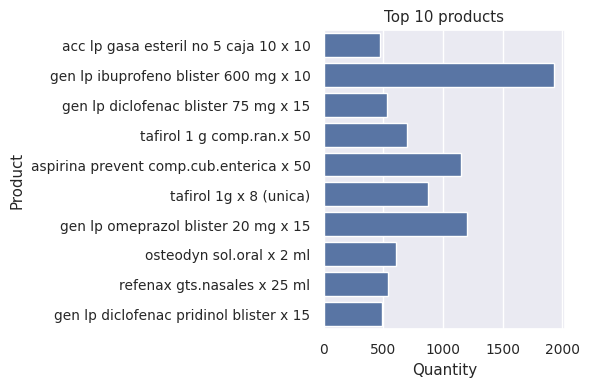

In [188]:
top_products = df['Producto'].value_counts().nlargest(10).index
plt.figure(figsize=(6, 4))
sns.countplot(data=df[df['Producto'].isin(top_products)],y='Producto')
plt.title(f'Top 10 products')
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [189]:
df['brand'] = df['Producto'].str.split().str[0]

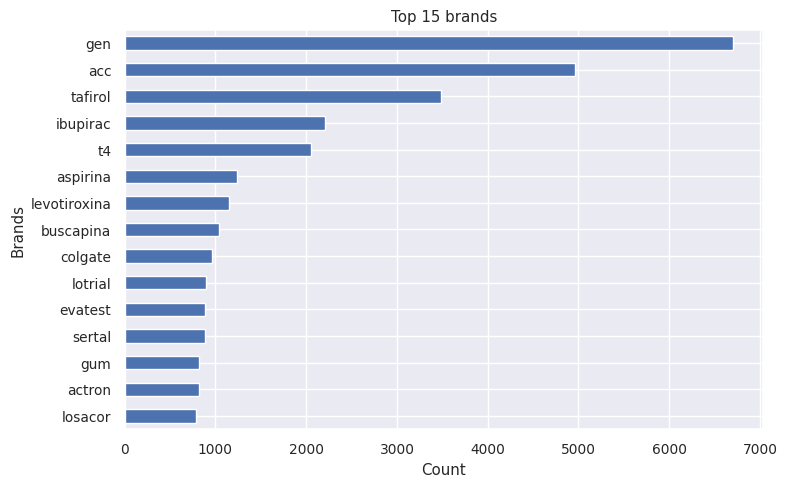

In [190]:
top_brands = df['brand'].value_counts().nlargest(15)
plt.figure(figsize=(8, 5))
top_brands.sort_values().plot(kind='barh')
plt.title('Top 15 brands')
plt.xlabel('Count')
plt.ylabel('Brands')
plt.tight_layout()
plt.show()

#### Observación: Inconsistencia en la estructura de nombres de productos
Al analizar el gráfico de 'Brands', se detecta que el método de extraer la primera palabra (str.split().str[0]) genera datos erróneos por tres razones principales:
- Nombres genéricos vs. marcas: muchos productos comienzan con el principio activo (ej: LEVOTIROXINA, ASPIRINA, DIFENHIDRAMINA) en lugar de la marca comercial. Esto infla artificialmente el conteo de "marcas" que en realidad son drogas genéricas.
- Marcas compuestas: Marcas como ACC LP, GEN LP o T4 MONTPELLIER se cortan a la mitad, perdiendo su identidad real (quedando solo como ACC, GEN o T4).
- Posición variable de la marca: en algunos registros, la marca no es la primera palabra. 
Por ejemplo:
    - PROMO DERMAGLOS SOLAR... (La marca es Dermaglós, pero el código toma Promo).   
    - KIT FARMACOLOR... (La marca es Farmacolor, pero toma Kit).   
    - CEPILLO GUM... (La marca es GUM, pero toma Cepillo).  
> - Procederemos a borrar todos los productos que se vendieron menos de 100 veces en todo el año de datos que tenemos.
> - Tambien haremos una revision a los nombres que tengan menos de 13 letras para verificar si queda algun error de tipografia donde no podamos sacar mas datos sobre el producto.

In [191]:
df = df[df["Producto"].map(df["Producto"].value_counts()) >= 100].copy()

In [192]:
mask = df["Producto"].fillna("").astype(str).str.len().le(12)
count_rows = mask.sum()
count_rows
df.loc[mask, "Producto"].astype(str).str.strip().value_counts()

Producto
dove (unica)    115
gum (unica)     108
Name: count, dtype: int64

In [193]:
df["Producto"].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10            1925
gen lp omeprazol blister 20 mg x 15              1203
aspirina prevent comp.cub.enterica x 50          1149
tafirol 1g x 8 (unica)                            870
tafirol 1 g comp.ran.x 50                         699
                                                 ... 
aucic 1% sol.oft.x 10 ml                          101
ibupirac 600 capsula blanda cáps.blandas x 50     101
kala md comp.rec.x 28                             101
acc lp borato de sodio x 25 gr                    101
alplax 2 mg comp.x 30                             100
Name: count, Length: 189, dtype: int64

#### **Nuestro siguiente paso es realizar una categorizacion a partir de la columna `Producto` donde crearemos la columna `product, dose, quantity` para clasificar los productos y poder entender mejor los datos.**

> - Se procede a realizar un data clean sobre la columna: este paso fue muy laborioso ya que el dataset tenia mucho ruido en esta columna precisamente, tuvimos que investigar sobre los tipos de presentaciones de cada medicamento y cada marca, aquí recurrimos a la fuente principal de consulta de información de donde provino el dataset.

In [194]:
df[["product", "dose", "quantity"]] = pd.NA

In [195]:
dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)                
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w))"""

df["dose"] = df["Producto"].str.findall(dose_pat).str.join(", ")
df["dose"] = df["dose"].str.replace(r"(?i)(?<!\w)(unica|única)(?!\w)", "UNICA", regex=True)
df["dose"] = df["dose"].replace("", np.nan)

> - Verificamos que productos quedan en blanco despues de nuestro filtro.

In [196]:
df[df["dose"].fillna("").eq("")][["Producto", "Rubro", "dose"]].value_counts()

Series([], Name: count, dtype: int64)

In [197]:
df[["Producto", "dose"]].value_counts()

Producto                                  dose     
gen lp ibuprofeno blister 600 mg x 10     600 mg       1925
gen lp omeprazol blister 20 mg x 15       20 mg        1203
tafirol 1g x 8 (unica)                    1g, UNICA     870
tafirol 1 g comp.ran.x 50                 1 g           699
gen lp diclofenac blister 75 mg x 15      75 mg         530
                                                       ... 
guantes (unica)                           UNICA         103
ultra corega crema sin sabor pomo x 20 g  20 g          103
vivita forte antigripal pouch x 1 x 5 g   5 g           103
aucic 1% sol.oft.x 10 ml                  1%            101
alplax 2 mg comp.x 30                     2 mg          100
Name: count, Length: 117, dtype: int64

> - Obtuvimos todas las dosis posibles y donde no existía un valor medible directamente decidimos dejarla en blanco con un NaN.
> - Ahora procederemos a trabajar la columna `quantity`.

In [198]:
prod = df["Producto"].fillna("").astype(str)

qty_pat = r"""(?ix)(
    
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b           

  
    \b(?:pomo|frasco|vial|amp(?:olla)?|sobre|sachet)\s*x?\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b

  
    \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b


    \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b


    \bx\s*\d{1,4}\s*(?:ds|dosis)?\b


    \b\d{1,3}x\d{1,3}\b)"""

df["quantity"] = prod.str.findall(qty_pat).str.join(", ")
df["quantity"] = df["quantity"].replace("", np.nan)


/tmp/ipykernel_2186/1255969322.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["quantity"] = df["quantity"].replace("", np.nan)


In [199]:
df[["Producto", "dose"]].value_counts().head(20)

Producto                                  dose     
gen lp ibuprofeno blister 600 mg x 10     600 mg       1925
gen lp omeprazol blister 20 mg x 15       20 mg        1203
tafirol 1g x 8 (unica)                    1g, UNICA     870
tafirol 1 g comp.ran.x 50                 1 g           699
gen lp diclofenac blister 75 mg x 15      75 mg         530
corbis 5 mg comp.rec.x 30                 5 mg          471
alikal (unica)                            UNICA         451
t4 montpellier 75 75 mcg comp.x 50        75 mcg        446
t4 montpellier 50 50 mcg comp.x 50        50 mcg        423
t4 montpellier 100 100 mcg comp.x 50      100 mcg       386
gen lp ibuprofeno blister 400 mg x 10     400 mg        368
acemuk 600 mg tab.eferv.x 10              600 mg        350
lotrial 10 mg comp.x 60                   10 mg         344
gen lp loratadina blister 10 mg x 10      10 mg         336
losacor 50 mg comp.rec.x 60               50 mg         306
carey (unica)                             UNICA 

> - Obtuvimos todas las cantidades posibles y donde no existia un valor medible directamente decidimos dejarla en blanco con un NaN.
> - Ahora procederemos a trabajar la columna `product`.

In [200]:
prod = df["Producto"].fillna("").astype(str)

dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w))"""

qty_remove_pat = r"""(?ix)(
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b
  | \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b
  | \bx\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b\d{1,3}x\d{1,3}\b)"""

p = (prod
     .str.replace(dose_pat, " ", regex=True)
     .str.replace(qty_remove_pat, " ", regex=True))


p = p.str.replace(r"(?ix)\s+\d{1,4}(?:\.\d+)?\s*$", " ", regex=True)

p = p.str.replace(r"(?ix)(?<!\w)x(?!\w)", " ", regex=True)

dose_num = df["dose"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand=False)

def drop_repeated_num(text, num):
    if not isinstance(num, str) or num == "" or num.lower() == "nan":
        return text
    return re.sub(rf"(?<!\w){re.escape(num)}(?!\w)", " ", text)

p = pd.Series(
    (drop_repeated_num(t, n) for t, n in zip(p.tolist(), dose_num.tolist())),index=df.index)

df["product"] = (p
    .str.replace(r"[^\w\sáéíóúñü]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .replace("", np.nan))

df["product"] = df["product"].str.replace(
    r"(?ix)\b(\w+)\b(?:\s+\1\b)+", r"\1", regex=True)

In [201]:
df["product"].isna().sum()

np.int64(0)

In [202]:
def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def norm(s) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = strip_accents(s)
    s = re.sub(r"\s+", " ", s)
    return s


EXACT = {
    
    "ibuprofeno": "ibuprofeno",
    "paracetamol": "paracetamol",
    "omeprazol": "omeprazol",
    "losartan": "losartán",
    "enalapril": "enalapril",
    "bisoprolol": "bisoprolol",
    "alprazolam": "alprazolam",
    "clonazepam": "clonazepam",
    "lactulosa": "lactulosa",
    "loratadina": "loratadina",
    "diclofenaco": "diclofenaco",
    "acetilcisteina": "acetilcisteína",
    "rosuvastatina": "rosuvastatina",
    "levotiroxina": "levotiroxina",
    "acido acetilsalicilico": "ácido acetilsalicílico",
    "acido acetilsalicilico + cafeina": "ácido acetilsalicílico + cafeína",
    "diclofenaco + pridinol": "diclofenaco + pridinol",
    "propinox + clonixinato de lisina": "propinox + clonixinato de lisina",
    "butilbromuro de hioscina + metamizol": "butilbromuro de hioscina + metamizol",
    "amoxicilina": "amoxicilina",
    "amoxicilina + acido clavulanico": "amoxicilina + ácido clavulánico",
    "colecalciferol (vitamina d3)": "colecalciferol (vitamina d3)",

    "tafirol": "paracetamol",
    "tafirol 500": "paracetamol",
    "tafirol forte": "paracetamol",
    "tafirol blister": "paracetamol",
    "geniol comp": "paracetamol",
    "mejoral paracetamol": "paracetamol",
    "paracetamol bayer": "paracetamol",
    "paracetamol raffo": "paracetamol",
    "paracetamol lazar": "paracetamol",
    "paracetamol teva": "paracetamol",

    "aspirina prevent comp cub enterica": "ácido acetilsalicílico",
    "bayaspirina": "ácido acetilsalicílico",
    "bayaspirina forte": "ácido acetilsalicílico",
    "aspirinetas": "ácido acetilsalicílico",
    "cafiaspirina": "ácido acetilsalicílico + cafeína",

    "t4 montpellier": "levotiroxina",
    "euthyrox": "levotiroxina",

    "lotrial": "enalapril",
    "corbis": "bisoprolol",
    "losacor": "losartán",
    "paxon": "losartán",
    "alplax": "alprazolam",
    "alplax net": "alprazolam",

    "rivotril": "clonazepam",
    "clonagin": "clonazepam",
    "clonagin sl": "clonazepam",
    "diocam": "clonazepam",
    "diocam sl": "clonazepam",

    "lactulon jbe": "lactulosa",

    "buscapina": "butilbromuro de hioscina",
    "buscapina fem": "butilbromuro de hioscina",
    "buscapina perlas": "butilbromuro de hioscina",
    "buscapina duo": "butilbromuro de hioscina",
    "buscapina duo got": "butilbromuro de hioscina",
    "buscapina compuesta": "butilbromuro de hioscina + metamizol",
    "buscapina compositum comp rec": "butilbromuro de hioscina + metamizol",

    "sertal": "propinox",
    "sertal perlas": "propinox",
    "sertal gts": "propinox",
    "sertal compuesto": "propinox + clonixinato de lisina",
    "sertal compuesto vl": "propinox + clonixinato de lisina",

    "ibupirac": "ibuprofeno",
    "actron 600 rapida accion caps gelat blanda": "ibuprofeno",
    "fabogesic 600 rapida accion cáps gelat blanda": "ibuprofeno",

    "acemuk": "acetilcisteína",
    "osteodyn": "colecalciferol (vitamina d3)",
    "osteodyn sol oral": "colecalciferol (vitamina d3)",
    "raquiferol d3 sol oral": "colecalciferol (vitamina d3)",
    "raquiferol d3 100000 ui": "colecalciferol (vitamina d3)",
    "sterogyl f a beb": "colecalciferol (vitamina d3)",
    "sinlip": "rosuvastatina",

    "gadopril": "enalapril",

  
    "valium": "diazepam",
    "zoloft": "sertralina",
    "asertral": "sertralina",
    "lexotanil": "bromazepam",
    "lexapro": "escitalopram",
    "aropax": "paroxetina",
    "paxil cr": "paroxetina",
    "dramamine": "dimenhidrinato",
    "reliveran": "metoclopramida",
    "novalgina": "metamizol",
    "novalgina jbe": "metamizol",
    "bactrim": "sulfametoxazol + trimetoprima",
    "bactrim forte": "sulfametoxazol + trimetoprima",
    "glucophage": "metformina",
    "glucophage xr comp lib prol": "metformina",
    "dbi metformina": "metformina",
    "dbi ap metformina": "metformina",
    "forxiga": "dapagliflozina",
    "lipitor": "atorvastatina",
    "atorvastatin richet": "atorvastatina",
    "atorvastan": "atorvastatina",
    "ventolin hfa aer inh c": "salbutamol",
    "ventolin sol p nebul": "salbutamol",
    "salbutral aer": "salbutamol",
    "atrovent hfa aerosol hfa": "ipratropio",
    "seretide diskus dosis": "fluticasona + salmeterol",
    "symbicort turbuhaler dosis": "budesonida + formoterol",
    "anoro ellipta pvo inh": "umeclidinio + vilanterol",

    "amoxidal": "amoxicilina",
    "amoxidal ped susp": "amoxicilina",
    "amoxidal duo": "amoxicilina + ácido clavulánico",
    "amoxidal duo susp": "amoxicilina + ácido clavulánico",
    "optamox duo": "amoxicilina + ácido clavulánico",
    "optamox duo susp": "amoxicilina + ácido clavulánico",
    "amixen clavulanico": "amoxicilina + ácido clavulánico",
    "amixen duo": "amoxicilina + ácido clavulánico",
    "amoclav duo": "amoxicilina + ácido clavulánico",}

GENERIC_PATTERNS = [
    (r"\bibuprofeno\b", "ibuprofeno"),
    (r"\bparacetamol\b", "paracetamol"),
    (r"\bdiclofenac", "diclofenaco"),
    (r"\bnaproxeno\b", "naproxeno"),
    (r"\bketorolac\b", "ketorolac"),
    (r"\ballopurinol\b", "allopurinol"),
    (r"\batenolol\b", "atenolol"),
    (r"\bpropranolol\b", "propranolol"),
    (r"\bcarvedilol\b", "carvedilol"),
    (r"\bclopidogrel\b", "clopidogrel"),
    (r"\bmetformina\b", "metformina"),
    (r"\batorvastat", "atorvastatina"),
    (r"\brosuvastatina\b", "rosuvastatina"),
    (r"\bespironolactona\b", "espironolactona"),
    (r"\bfurosemida\b", "furosemida"),
    (r"\blosartan\b", "losartán"),
    (r"\benalapril\b", "enalapril"),
    (r"\bbisoprolol\b", "bisoprolol"),
    (r"\bomeprazol\b", "omeprazol"),
    (r"\blesomeprazol\b", "esomeprazol"),
    (r"\blevotiroxina\b", "levotiroxina"),
    (r"\bamoxicilina\b", "amoxicilina"),
    (r"\bcefalexina\b", "cefalexina"),
    (r"\bclindamicina\b", "clindamicina"),
    (r"\bciprofloxacina\b", "ciprofloxacina"),
    (r"\bnorfloxacina\b", "norfloxacina"),
    (r"\bazitromicina\b", "azitromicina"),
    (r"\bfluconazol\b", "fluconazol"),
    (r"\bnistatina\b", "nistatina"),
    (r"\bsildenafil\b", "sildenafil"),
    (r"\baciclovir\b", "aciclovir"),
    (r"\bcarbamazepina\b", "carbamazepina"),
    (r"\blamotrig", "lamotrigina"),
    (r"\bmemantina\b", "memantina"),
    (r"\bfinaster", "finasterida"),
    (r"\btamsulosina\b", "tamsulosina"),
    (r"\bsertralina\b", "sertralina"),
    (r"\bfluoxet", "fluoxetina"),
    (r"\bes(c|s)italopram\b", "escitalopram"),
    (r"\bparoxetina\b", "paroxetina"),
    (r"\bdiazepam\b", "diazepam"),
    (r"\bbromazepam\b", "bromazepam"),
    (r"\brisperid", "risperidona"),
    (r"\bquetiapin", "quetiapina"),
    (r"\bhaloperidol\b", "haloperidol"),
    (r"\bloratadina\b", "loratadina"),
    (r"\bdifenhidramina\b", "difenhidramina"),
    (r"\bsalbutamol\b", "salbutamol"),
    (r"\bipratropio\b", "ipratropio"),
    (r"\bfluticasona\b", "fluticasona"),
    (r"\bsalmeterol\b", "salmeterol"),
    (r"\bbudesonida\b", "budesonida"),
    (r"\bformoterol\b", "formoterol"),
    (r"\bmometasona\b", "mometasona"),
    (r"\bmetoclopramida\b", "metoclopramida"),
    (r"\bmetamizol\b", "metamizol"),
    (r"\bacetilcisteina\b", "acetilcisteína"),
    (r"\blactulosa\b", "lactulosa"),
    (r"\bcolecalciferol\b", "colecalciferol (vitamina d3)"),
    (r"\bcalcitriol\b", "calcitriol"),
    (r"\blidocaina\b", "lidocaína"),
    (r"\bterbinafina\b", "terbinafina"),
    (r"\bbeta(histina)?\b", "betahistina"),
    (r"\bdapaglifloz", "dapagliflozina"),]

AMBIGUOUS = {
    "carey",
    "diurex", "diurex a",
    "qura", "qura plus",
    "migral", "migral ii", "migral compuesto", "migral compositum",
    "alikal", "alikal expend c prosp",
    "refrianex", "refrianex compuesto",
    "mylanta", "mylanta extra", "mylanta ii", "mylanta simple liq", "mylanta limon",
    "mylanta frut silv", "mylanta tabletas", "mylanta extra tableta",
    "supradyn forte", "supradyn pronatal", "supradyn forte eferv nar s az",
    "berocca plus",
    "uvasal sob doble", "uvasal naranja sob doble", "uvasal limon sob doble",
    "uvasal naranja fco", "uvasal fco plast",
    "next", "next forte", "next plus",
    "vick vitapyrena", "vick vitapyrena forte miel limon", "vick forte",
    "vick vaporub lata", "vick vaporub pote",
    "redoxon eferv limon", "redoxon eferv",
    "redoxitos plus sachets gomitas", "redoxitos naranja masticables sachets gomitas",
    "centrum mujer", "centrum silver",
    "corbis d", "lotrial d", "losacor a", "losacor d", "gadopril d",
    "paxon d", "losartan richet trzb",}

def map_active(product_name: str):
    s0 = norm(product_name)
    if not s0:
        return "Desconocido", "empty"

 
    if s0 in AMBIGUOUS:
        return "Desconocido", "ambiguous_or_unknown"

    
    if s0.startswith("gen lp "):
        rest = s0.replace("gen lp ", "", 1).strip()
        rest = rest.replace("clavulanico", "acido clavulanico")

        if rest in EXACT:
            return EXACT[rest], "gen_lp_exact"

        for pat, active in GENERIC_PATTERNS:
            if re.search(pat, rest):
                return active, "gen_lp_pattern"

        return "Desconocido", "gen_lp_unresolved"

   
    if s0 in EXACT:
        return EXACT[s0], "exact"

  
    for pat, active in GENERIC_PATTERNS:
        if re.search(pat, s0):
            return active, "pattern"

 
    if re.search(r"\b(acc lp|perfumeria|accesorio|guantes|curita|curitas|barbijo|test|algodon|gasa|jeringa|venda|cepillo|colgate|dove|nivea|gillette|labello|listerine|rexona|ponds|garnier|pantene)\b", s0):
        return "Desconocido", "non_drug_or_device"

    return "Desconocido", "unknown"

mapped = df["product"].apply(map_active)

active = mapped.apply(lambda x: x[0])

mask = active != "Desconocido"
df.loc[mask, "product"] = active[mask]
print("Reemplazados:", int(mask.sum()))

Reemplazados: 21159


In [203]:
df['Mes'] = df['Fecha'].dt.to_period('M')

In [204]:
df['Día'] = df['Fecha'].dt.day

In [205]:
df['Mes']

8         2025-01
9         2025-01
13        2025-01
15        2025-01
16        2025-01
           ...   
117281    2025-12
117286    2025-12
117288    2025-12
117289    2025-12
117290    2025-12
Name: Mes, Length: 41107, dtype: period[M]

In [206]:
df['Día']

8          1
9          2
13         2
15         2
16         2
          ..
117281    23
117286    23
117288    23
117289    23
117290    23
Name: Día, Length: 41107, dtype: int32

In [207]:
ventas = (df.groupby(['Mes', 'Producto'])['Cant'].sum().reset_index())

In [208]:
top_5_mensual = (ventas.sort_values(['Mes', 'Cant'], ascending=[True, False]).groupby('Mes').head(5))

In [209]:
top_5_mensual

,Mes,Producto,Cant
44,2025-01,buscapina compositum comp.rec.x 20,383
155,2025-01,sertal compuesto comp.rec.x 20,260
82,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
87,2025-01,gen lp omeprazol blister 20 mg x 15,163
168,2025-01,tafirol 1 g comp.ran.x 24,156
229,2025-02,buscapina compositum comp.rec.x 20,252
267,2025-02,gen lp ibuprofeno blister 600 mg x 10,190
332,2025-02,qura plus comp.rec.x 20,186
341,2025-02,sertal compuesto comp.rec.x 20,182
272,2025-02,gen lp omeprazol blister 20 mg x 15,151


In [210]:
ventas_mensuales = (df.groupby(['Mes', 'Producto'], as_index=False)['Cant'].sum())

In [211]:
top_100_mensual = (ventas_mensuales.sort_values(['Mes', 'Cant'], ascending=[True, False]).groupby('Mes').head(100))

In [212]:
top_100_mensual

,Mes,Producto,Cant
44,2025-01,buscapina compositum comp.rec.x 20,383
155,2025-01,sertal compuesto comp.rec.x 20,260
82,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
87,2025-01,gen lp omeprazol blister 20 mg x 15,163
168,2025-01,tafirol 1 g comp.ran.x 24,156
...,...,...,...
2125,2025-12,corteroid retard iny.f.a.x 1 x 2 ml,11
2162,2025-12,guantes (unica),11
2168,2025-12,hexaler nasal spray nasal x 120 ds.,11
2170,2025-12,hipoglos pda.x 50 g,11


In [213]:
enero = df[df['Mes'] == '2025-01']

In [214]:
top_enero = top_100_mensual[top_100_mensual['Mes'] == '2025-01']

In [215]:
top_enero

,Mes,Producto,Cant
44,2025-01,buscapina compositum comp.rec.x 20,383
155,2025-01,sertal compuesto comp.rec.x 20,260
82,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
87,2025-01,gen lp omeprazol blister 20 mg x 15,163
168,2025-01,tafirol 1 g comp.ran.x 24,156
...,...,...,...
113,2025-01,levotiroxina gsk 100 mcg comp.x 50,16
116,2025-01,levotiroxina gsk 88 mcg comp.x 50,16
133,2025-01,norgestrel max unidosis comp.x 1,16
138,2025-01,paxon 50 mg comp.rec.x 60,16


In [216]:
df['Producto'] = df['Producto'].str.strip().str.lower()
df['Mes'] = df['Fecha'].dt.to_period('M')

ventas = (df.groupby(['Mes', 'Producto'], as_index=False)['Cant'].sum())

ventas['rank'] = ventas.groupby('Mes')['Cant'].rank(method='first',ascending=False)

top_100_por_mes = ventas[ventas['rank'] <= 100].sort_values(['Mes', 'rank'])

top_100_por_mes = top_100_por_mes.reset_index(drop=True)

In [217]:
top_100_por_mes.head(20)

,Mes,Producto,Cant,rank
0,2025-01,buscapina compositum comp.rec.x 20,383,1.0
1,2025-01,sertal compuesto comp.rec.x 20,260,2.0
2,2025-01,gen lp ibuprofeno blister 600 mg x 10,210,3.0
3,2025-01,gen lp omeprazol blister 20 mg x 15,163,4.0
4,2025-01,tafirol 1 g comp.ran.x 24,156,5.0
5,2025-01,mylanta extra comp.mast.x 24,155,6.0
6,2025-01,alikal (unica),143,7.0
7,2025-01,bayaspirina comp.x 30,113,8.0
8,2025-01,aspirina prevent comp.cub.enterica x 50,112,9.0
9,2025-01,osteodyn sol.oral x 2 ml,79,10.0


<Figure size 1200x800 with 0 Axes>

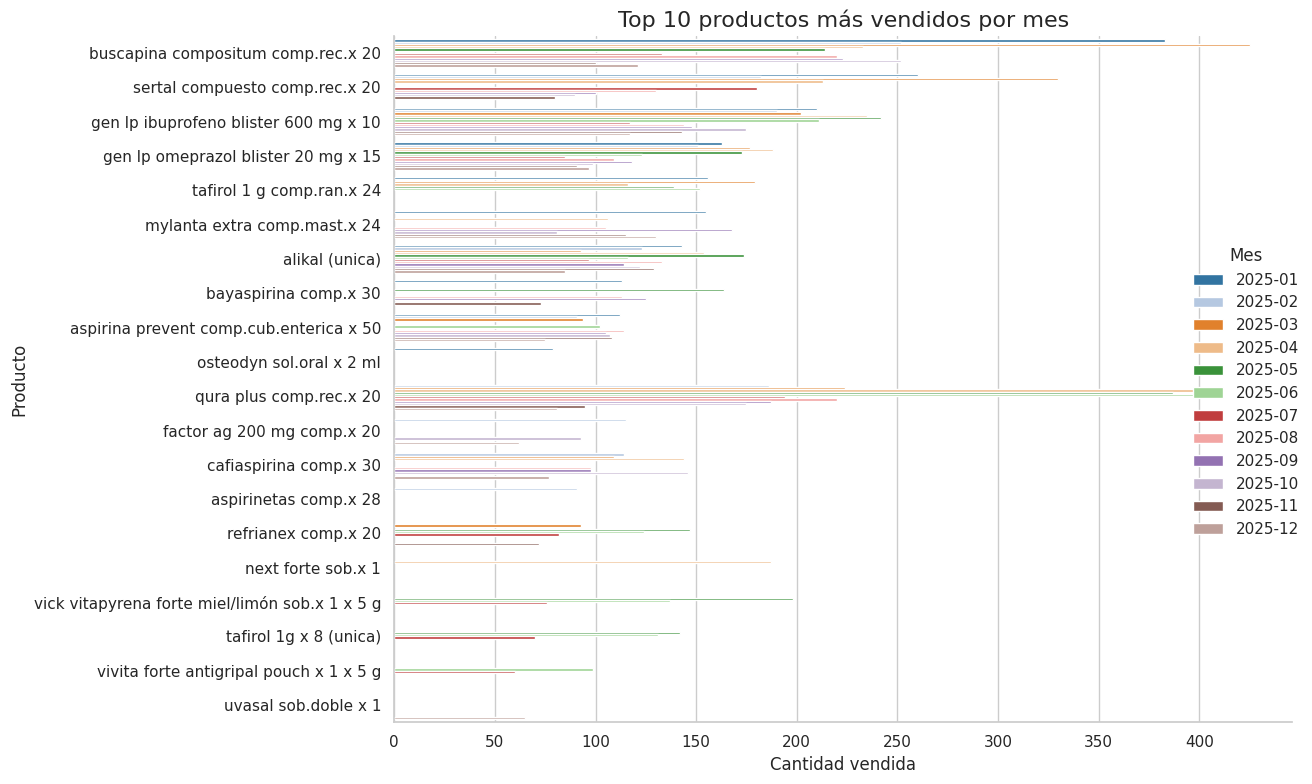

In [218]:
top_10_por_mes = top_100_por_mes[top_100_por_mes['rank'] <= 10]
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

g = sns.catplot(
    data=top_10_por_mes,
    x='Cant', 
    y='Producto', 
    hue='Mes',
    kind='bar',
    height=8, 
    aspect=1.5,
    palette="tab20")

plt.title("Top 10 productos más vendidos por mes", fontsize=16)
plt.xlabel("Cantidad vendida", fontsize=12)
plt.ylabel("Producto", fontsize=12)
plt.tight_layout()

plt.show()

/tmp/ipykernel_2186/3699682197.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


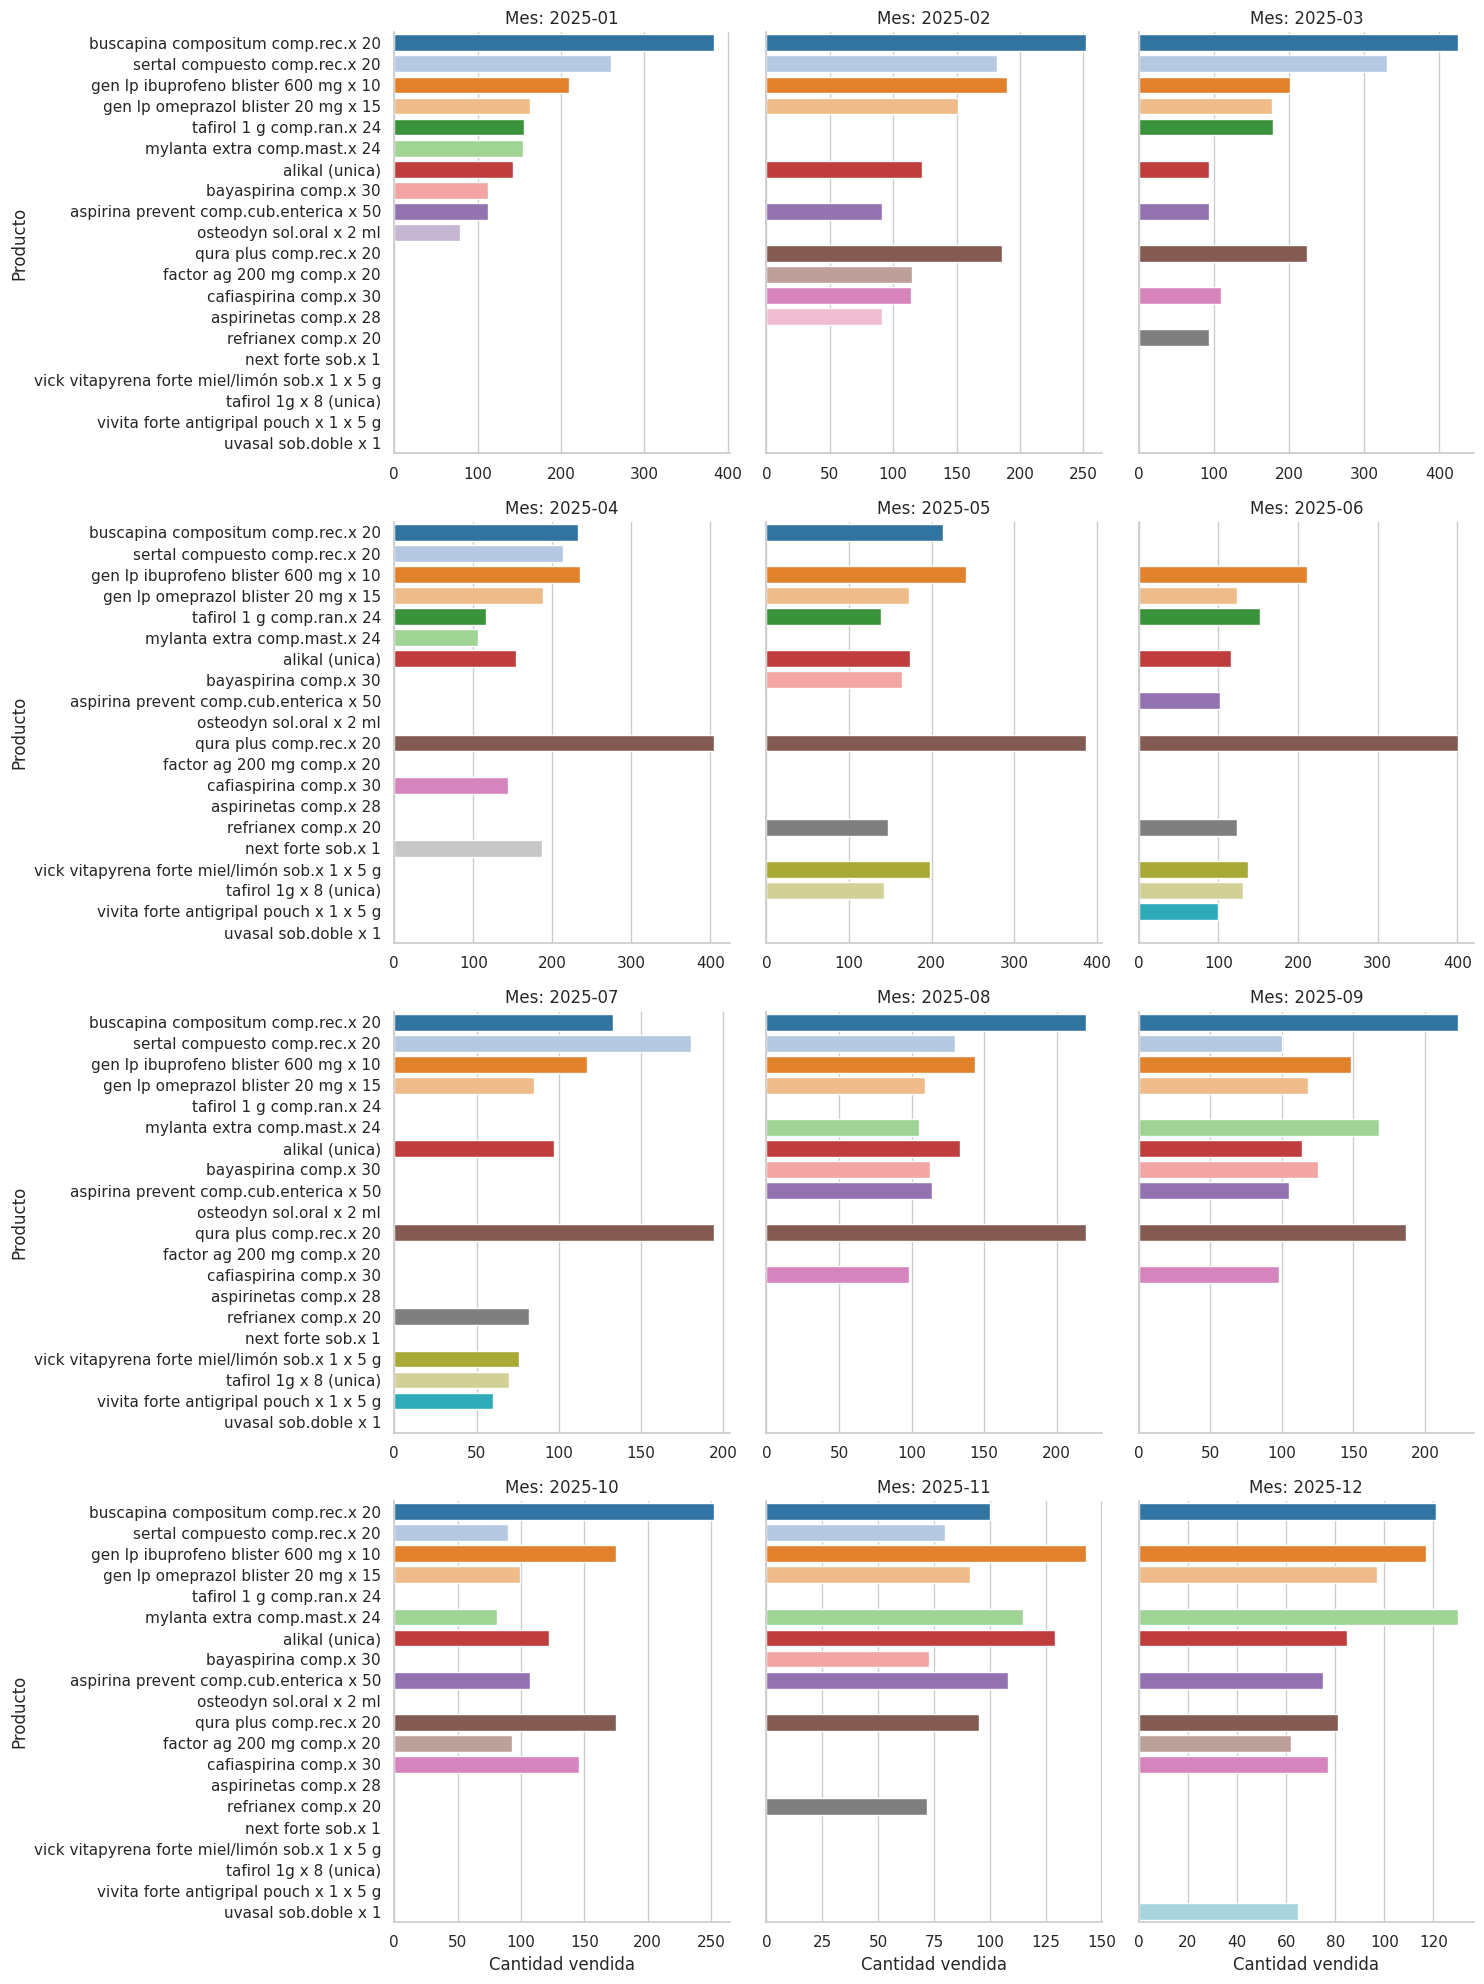

In [219]:
g = sns.catplot(
    data=top_10_por_mes,
    x='Cant',
    y='Producto',
    col='Mes',
    kind='bar',
    col_wrap=3,
    height=5,
    sharex=False,
    palette="tab20")
g.set_titles("Mes: {col_name}")
g.set_axis_labels("Cantidad vendida", "Producto")
plt.tight_layout()
plt.show()

In [220]:
ventas_pivot = top_100_por_mes.pivot_table(
    index='Producto',
    columns='Mes',
    values='Cant',
    aggfunc='sum',
    fill_value=0)

ventas_pivot['Total'] = ventas_pivot.sum(axis=1)
top30_productos = ventas_pivot.sort_values('Total', ascending=False).head(30).drop('Total', axis=1)

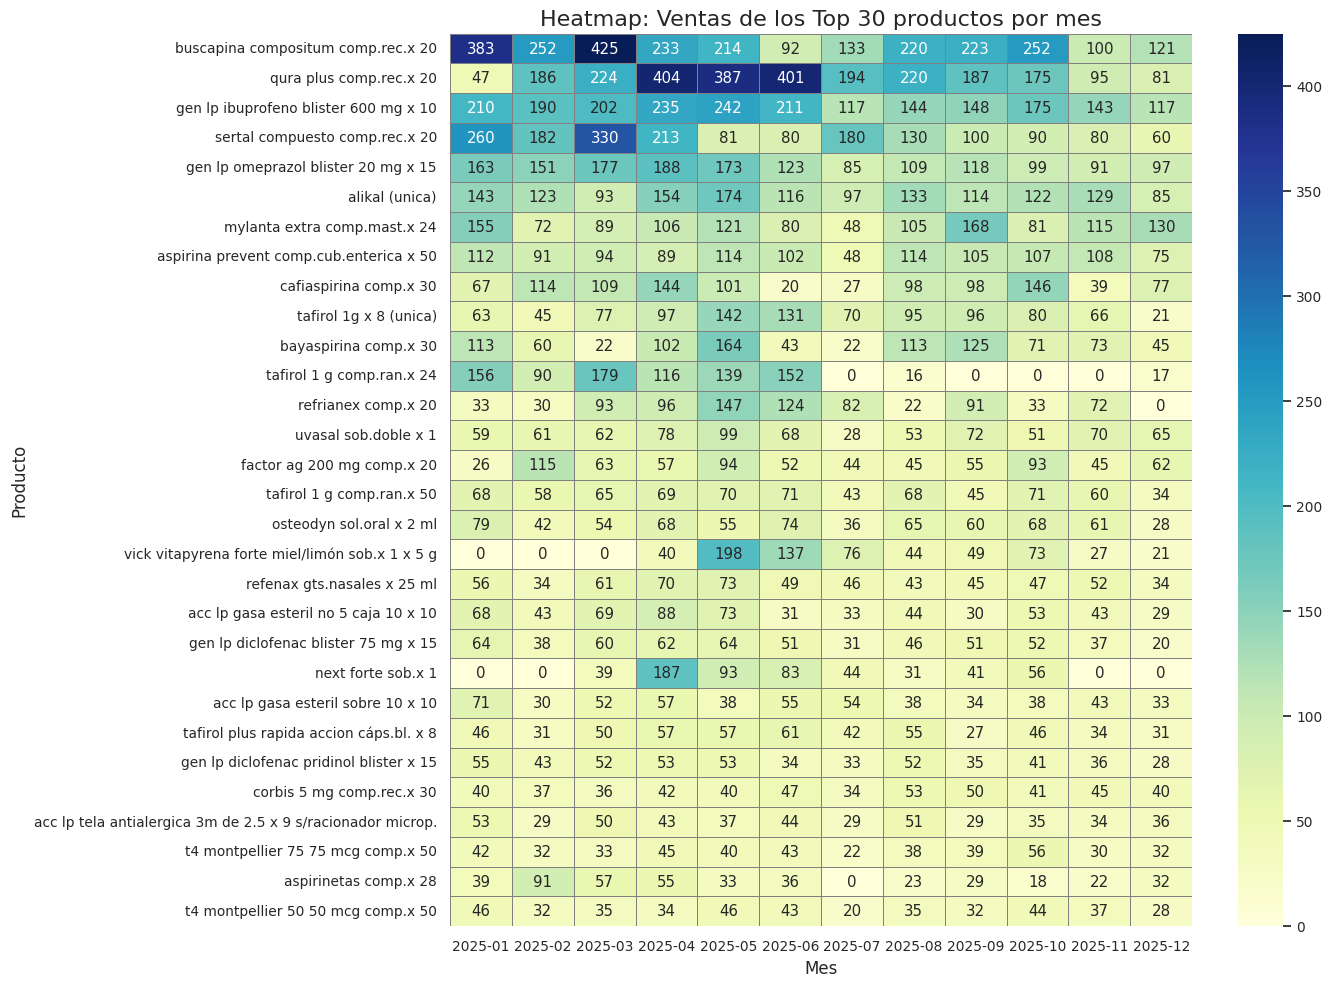

In [221]:
plt.figure(figsize=(14, 10))
sns.set(font_scale=0.9)
sns.heatmap(top30_productos,cmap="YlGnBu",linewidths=0.5,linecolor='gray',annot=True,fmt=".0f")
plt.title("Heatmap: Ventas de los Top 30 productos por mes", fontsize=16)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Producto", fontsize=12)
plt.tight_layout()
plt.show()

#### **Continuaremos con la columna `Producto` donde crearemos la columna `form` para clasificar los productos por su presentacion y poder entender mejor los datos.**

In [222]:
def pharmacy_products(texto):
    if pd.isna(texto):
        return 'Unknown'
    
    texto = texto.lower()
    
    if 'comp' in texto:
        return 'Comprimido'
    elif 'gel' in texto:
        return 'Gel'
    elif 'susp' in texto:
        return 'Suspensión'
    elif 'colirio' in texto:
        return 'Colirio'
    elif 'jarabe' in texto:
        return 'Jarabe'
    elif 'caps' in texto or 'cáps' in texto:
        return 'Cápsula'
    else:
        return 'Otros'

df['form'] = df['Producto'].apply(pharmacy_products)

In [223]:
df['form'].value_counts()

form
Otros         20870
Comprimido    17281
Cápsula        2172
Gel             477
Suspensión      307
Name: count, dtype: int64

> - Entendemos que hay demasiada cantidad de productos para las pocas cantidad de grupos, lo cual nos hace entender que la investigación tiene que ser mas detallada.

In [224]:
pharmaceutical_classifier = {
    'Salud Cardiovascular': ['alpertan', 'sartan', 'pril', 'olol', 'dipino', 'estatina', 'lipitor', 'lipokemia',
        'aspirina prevent', 'valsarfec', 'tervalon', 'ateronova', 'blokium', 'befol', 'furosemida', 'lipomax', 'combinater',
        'torivas', 'aspirinetas', 'racorval', 'atenolol', 'enalapril', 'amlodipina', 'rovartal', 'mecanyl', 'paraclim', 'oldren', 'lercadip',
        'losartan', 'amloc', 'cardio', 'aldactone', 'lotrial', 'simultan', 'arteriosan', 'nebicor', 'sarmec', 'lonikan', 'infiltrex', 'tetrazic',
        'diurex', 'rosustatin', 'rovastane', 'epistal', 'minuslip', 'regulip', 'medocor', 'bisofec', 'nebilet', 'tensimed',
        'carrier', 'meplar', 'losacor', 'prinil', 'lipifen', 'dilcoran', 'acalix', 'rosufen', 'syncrocor', 'letondal',
        'ateroclar', 'aturen', 'daunlip', 'espironol', 'filten', 'pelmec', 'rosufec', 'aclusin', 'tacicul', 'edagan',
        'bilip', 'bertel', 'nabila', 'corbis', 'diapresan', 'ixium', 'azecar', 'veraten', 'clopidogrel', 'astende',
        'acalik', 'atenix', 'indalten', 'glioten', 'diocam', 'meridian', 'dipemina', 'valpex', 'loctenk', 'zarator', 'loplac',
        'ilduc', 'bisopil', 'prisonil', 'sinlip', 'blavin', 'nivas', 'ultrex', 'vasotenal', 'antipresol', 'minicam', 'lasix',
        'sarval', 'atorvastatin', 'lostam', 'peptazol', 'vastarel', 'coracil', 'euretico', 'antiplaq', 'drimux',
        'ixacor', 'rosuvast', 'sistatin', 'tacardia', 'tanavat', 'renitec', 'crestor', 'flebosmina', 'enatral', 'pixaban',
        'montrate', 'corpres', 'endial', 'explaner', 'diural', 'pgb 75', 'diovan', 'togrel', 'clarimax', 'acantex',
        'aceno', 'acenocoumarol', 'alental', 'alipas', 'amix', 'amlodicord', 'amlodisane', 'amlopaw', 'aplacasse', 'aterva',
        'atucha', 'belozok', 'bempezet', 'benlipid', 'biascor', 'bicardil', 'bisofec', 'candesartan', 'cardionorm', 'cardiorex', 'carflax',
        'carvedil', 'carvedilol', 'cilos', 'cilostal', 'cilostazol', 'clodrel', 'clopilep', 'corosan', 'coroval', 'coverene', 'cozaarex', 'cristaclar',
        'oldinot', 'reovex', 'cvp flebo', 'drinax', 'atlansil', 'zocor', 'lipex', 'incoril', 'natrilix', 'irazem', 'rolast', 'plenacor', 'lopid', 'procardia', 
        'diondel', 'rostazina', 'policor', 'presimax', 'micardis', 'atorvastan', 'rosuber', 'tritab', 'tonibral', 'toltem', 'delak', 'pleyar', 'dilatrend', 'desaler', 
        'noster', 'sintrom', 'atarva', 'nifed sol', 'terloc', 'vytorin', 'rospower36', 'exforge', 'kemoter', 'pravil duncan', 'exforge', 
        'lonikan', 'infiltrex', 'tetrazic', 'lisaler', 'periplum', 'pivast', 'nodis', 'tencas', 'plidex', 'pravil duncan', 'exforge', 'verboril', 'zundic',
        'rentop', 'blastop', 'eplerona', 'nonlipid', 'novurit', 'gadocor', 'lagotran', 'etacril', 'sinaler', 'lebocar', 'evoquin',
        'vigicer', 'circuvit', 'recupel', 'sotacor', 'fenofibrato micronizado richet', 'rosucol', 'atacand', 'lunel 75 practidosis',
        'ristonel', 'vorst', 'craveril', 'hiperval', 'odranal', 'plidan', 'ezetrol', 'rociamin', 'vastina', 'firialta',
        'bigetric', 'duerix', 'nirpol', 'tritace', 'denverkast', 'treg', 'joker flex', 'finlipol', 'biorgan'],
    
    'Salud Mental / Sistema Nervioso': ['pisono', 'alplax', 'alprazolam', 'clonazepam', 'diazepam', 'fanter', 'lanx', 'equilibrane', 'remeron', 'topictal',
        'sertralina', 'fluoxetina', 'lexapro', 'psicoasten', 'quetiapina', 'somit', 'clonagin', 'trapax', 'noches', 'lucidex', 'eumotil',
        'lamotrigina', 'zepam', 'latrigin', 'paxon', 'risperin', 'novo', 'asertral', 'ivestron', 'madopar', 'taxagon ad', 'lamocas', 'meleril', 'dormiro',
        'psicotil', 'rivotril', 'tiarix', 'ampliar', 'ultraneural', 'migral', 'clonagin', 'trastocir', 'duxetin', 'trastocir', 'rostrum',
        'gavin', 'insertec', 'lextor', 'lexotanil', 'tranquinal', 'comenter', 'remizeral', 'aropax', 'quetiazic', 'discretal', 'quetiaros',
        'neuryl', 'emotival', 'serubel', 'valium', 'carbamazepina', 'memantina', 'zoloft', 'depakene', 'elafax', 'neuristan', 'cabal',
        'inductal', 'epamin', 'mestinon', 'melatol', 'armonil', 'modaton', 'climatix', 'audax', 'anafranil', 'tegretol', 'merital', 'sesaren',
        'actinerval', 'actison', 'akineton', 'alzepral', 'amiptril', 'ampk', 'anafranil', 'anelka', 'atemperator', 'biatrix', 'biperideno',
        'brintellix', 'ceglution', 'clonadane', 'clonax', 'conexine', 'conformal', 'consiv', 'continex', 'cuait', 'humorap', 'meleril', 'dormi-ros',
        'seroquel', 'neutop', 'deslafax', 'nocte', 'alprazol', 'afenexil', 'tueris', 'dominium', 'circonyl', 'lyrica', 'talpram', 'kanbis', 'optiser',
        'petrium', 'zentius', 'tryptanol', 'rediun', 'lamirax', 'audipax', 'ataraxone', 'paxil', 'donepes', 'mystika', 'rohypnol', 'pristiq', 'meibi',
        'valcote', 'dacten', 'lamictal', 'meprozin', 'etiasel', 'moperidona af', 'revertrix', 'aurene', 'rabloc', 'nitrodom', 'hipolipol',
        'neurontin', 'zenelis mareos', 'midax', 'xanax', 'zolodorm', 'lioresal', 'inquetia', 'rostalopram', 'valeriana', 'segren', 'kabian 100', 'equitone'],

    'Salud Digestiva': ['alumpak', 'alverin', 'almax', 'omeprazol', 'pantoprazol', 'reflux', 'dulcolax', 'gastromax', 'rogastril', 'miopropan', 'genoprazol', 'barex',
        'lanzoprazol', 'aci-tip', 'agarol', 'buscapina', 'bagohepat', 'lactulon', 'sinulcus', 'peptazol', 'esoprazol', 'deblax', 'anusol',
        'chofitol', 'bismuto', 'oligoplex', 'mylanta', 'taural', 'bicarbonato', 'qg5', 'sincerum', 'mudantil', 'reliveran', 'pantus', 'pantus',
        'alikal', 'sertal', 'regulane', 'axiomat', 'loperamida', 'ulcozol', 'lactulon', 'mutum', 'zoltenk', 'mebutar', 'remexal',
        'suerox', 'vorpix', 'aziatop', 'uvasal', 'rennie', 'hepatalgina', 'aglucide', 'acimed', 'esomepra', 'dexopral', 'antihemorroidal', 'prune iii', 'subical',
        'biletan', 'agiolax', 'reliveran', 'malvahp', 'genoprazol', 'gastromax', 'enterogermina', 'sucralfato', 'lorebil', 'dulcolax', 'actual comp', 'gastec',
        'aci-tip', 'acimed', 'agarol', 'agiolax', 'alverin', 'ansielix', 'apasmo', 'barex', 'carbogasol', 'carbon', 'cascara', 'ciruela', 'ciruelax', 'creon',
        'pantocas', 'eudon', 'paratropina', 'rempec', 'panastat', 'xilocler', 'fosfalax', 'ricino', 'bil', 'dramamine', 'lemil pvo', 'laxamin',
        'nikzon', 'urdecole', 'ilotcina', 'pantop', 'enemol', 'floratil', 'carmin', 'ilotcina', 'actual bl', 'plenica', 'desaler', 'lanzopral',
        'proctyl', 'spasmoctyl', 'laragon', 'iloticina', 'fosfo', 'diaris', 'nexium', 'sarmec', 'esodar', 'mosar', 'procto-ikatral', 'vermicet', 'pentasa', 'procto',
        'diar', 'vedipal', 'omecap', 'medilaxan', 'vecetam', 'nastizol', 'ultraprazol', 'lopecian', 'digecaps', 'molagar'],

    'Salud Sexual / Urología': ['nafil', 'dalafil', 'sildenafil', 'tadalafil', 'vimax', 'lubricante', 'invictus'],

    'Oftalmología': ['alphagan', 'ofta', 'colirio', 'timolol', 'latanoprost', 'lágrimas', 'idena', 'latlas', 'coltix', 'isis', 'flarex', 'latano',
        'gotas', 'tobrex', 'gatidex', 'soloftlmica', 'tobradex', 'sensu', 'natax', 'fotamicin', 'arlyt', 'plostim', 'flarex', 'tansiloprost',
        'restasis', 'systane', 'aucic', 'irix', 'opti free', 'gota pc', 'timed', 'quidex', 'coltix', 'latlas', 'gotabiotic', 'gtsoftx', 'lagrima',
        'acrylarm', 'alcon', 'alosol', 'arlyt', 'artelac', 'aucic', 'azarga', 'azopt', 'berlofen', 'bideon', 'eyes', 'brimopress', 'brit', 'brixia', 'cipos', 'closporil', 'coltix',
        'lagrimas', 'lagrima dorf', 'osiris sol', 'olopat', 'inmunosporin', 'glaucotensil', 'tears', 'tolf emuls', 'mirus sol', 'proflax', 'travatan',
        'ketif solx', 'glaucoprost', 'patanol', 'latanoflax', 'ocurel lc sol', 'ketif', 'newclar', 'isoptomax', 'ketif sol', 'isoptomax', 'tralerc lc',
        'fotadex', 'rifamicyn', 'tacines', 'dorlamida', 'lubrol', 'xalatan'],

    'Antibióticos': ['cilina', 'micina', 'floxacino', 'cicli', 'cef', 'amoxi', 'poviral', 'leflumax', 'nixoran', 'ivercass',
        'clavulanico', 'ceporexin', 'triamid', 'debril', 'nabratin', 'macril', 'bactrim', 'misultina', 'furadantina mc', 'dalacin c',
        'poviral', 'bactifren', 'leflumax', 'nixoran', 'azibiotic', 'flagyl', 'cronopen', 'dalacin c', 'urofuran', 'keforal',
        'acantex', 'acifusin', 'amikacina', 'amixen', 'amoclav', 'amoxicilina', 'amoxidal', 'amoxol', 'arotran', 'nexpeci', 'silfab pix',
        'asolmicina', 'avelox', 'azibiotic', 'azitromicina', 'azitrox', 'bactifren', 'bactrim', 'bioclavid', 'biotic', 'cefacar', 'cefalexina', 'cetaxim', 'ciriax',
        'claribiotic', 'clarimax', 'claritrom', 'claritromicina', 'clarovil', 'clavulox', 'clidan', 'clindacin', 'clindacur', 'clindamicina', 
        'xiclovir', 'pen di ben', 'nitrofurazona', 'estreptocarbocaftiazol', 'lisovyr', 'oralsone', 'metronidazol', 'nistatina',
        'nexpecil', 'rifadom', 'macromax'],

    'Antimicóticos': ['fluconazol', 'fangan', 'terekol', 'fungueal', 'micoral', 'itrac', 'terbenol duo', 'flupec', 'medifungol',
                      'perfungol', 'fungo nail', 'micotral', 'mycanden', 'ivertal'],

    'Analgésicos / Antiinflamatorios': ['profeno', 'fenaco', 'coxib', 'paracetamol', 'aspirina', 'fungocina', 'unesia', 'dorixina', 'mafel 200', 'diclo',
        'dol', 'clonixinato', 'mejoral', 'geniol', 'meloxicam', 'muelita', 'fabogesic', 'actron', 'next', 'tetralgin', 'sinalgico',
        'dioxaflex', 'ketorolac', 'tafirol', 'naprux', 'diclofenac', 'artrosil', 'anaflex', 'procetoken', 'liparex', 'gargaletas', 'serrapep',
        'prontal', 'ibu', 'evanol', 'diclomar', 'flogocox', 'bengue', 'ponstil', 'tetralgin', 'sinalgico', 'desinflamante', 'ernex', 'tryptalgin',
        'acloxigenac', 'actron', 'algicur', 'algispray', 'alikal', 'anaflex', 'arcoxia', 'arnica', 'artrosil', 'artrostop', 'aspirina', 'aspirinetas',
        'atomo', 'bayaspirina', 'befol', 'bengue', 'blokium', 'calmador', 'contractil', 'enantyum', 'migratriptan', 'predual', 'flexina', 'rodinac flex',
        'naprontag', 'rodinac', 'xumer', 'naprontag', 'diclogesic', 'naprontag', 'falgos', 'im 75 montpellier', 'fluticort', 'flumetol', 'lopred', 'otex hc',
        'otosporin', 'tetralg', 'talgiax', 'supracam', 'tetralg', 'talgiax', 'paravetamol', 'novalgina', 'ultragesic cb', 'flexresan'],

    'Salud Respiratoria / Antialérgicos': ['tadina', 'rizina', 'nasona', 'terol', 'ambroxol', 'mucol', 'frevia', 'alernix', 'aerotina', 
                                           'alercas', 'acemuk', 'aerius', 'frenadol', 'antigripal', 'ventolin', 'athos', 'relvar', 'neumocort', 
                                           'nasal', 'lukast', 'aliviatos', 'caramelos', 'refrianex', 'salbutamol', 'otoclean', 'novacler', 'pulmosan',
        'asmavitan', 'seretide', 'refenax', 'lidil', 'cedric', 'flutivent', 'collubiazol', 'pulmocler', 'salbutral', 'cetizine', 'refrianex', 'proetzonide',
        'acemuk', 'aerius', 'aerogal', 'aerolep', 'aerotina', 'aerotrop', 'aerovent', 'aeroxina', 'aireal', 'alergitrat', 'alermina', 'alerpriv', 'alertial',
        'aliviatos', 'anoro', 'aseptobron', 'asmabron', 'asmavitan', 'atrophen', 'atrovent', 'benadryl', 'bisolhelix', 'bisolvon', 'bronax', 'bronquisedan', 
        'bronsol', 'bucoangin', 'bucogel', 'bucotricin', 'budesonida', 'butocort', 'cedrimuc', 'cetriler', 'flixotide', 'kanbis sol oral', 'allegra', 'neumotide',
        'neumotex', 'filotricin', 'supraler', 'salbuden', 'lisi', 'symbicort', 'lafedryl', 'febratic', 'termofren', 'acc expectorante', 'incruse ellipta',
        'fluticort', 'flumetol', 'lopred', 'otex hc', 'neumotropio', 'aliviapres', 'decidex grip', 'resaquit', 'levomine', 'spiriva', 'decidex', 'proair bronquial',
        'expectosan antitusivo', 'febrigrip', 'ismigen', 'octanyl', 'rino-b nebu', 'tukol ac', 'tukol miel y tomillo', 'pulmonix grip','tukol buc miel',
        'kipergrip', 'plenair'],

    'Antialérgicos': ['dexalergin', 'hexaler', 'frenaler', 'difenhidramina', 'cortipyren'],

    'Higiene y Cuidado Personal': ['shampoo', 'acondicionador', 'jabon', 'desodorante', 'axe', 'st ives', 'fluordent', 'plac out', 'dentilac', 'evagina', 'trim', 'gel',
        'dove', 'colgate', 'pasta dental', 'cepillo', 'hilo dental', 'gillette', 'listerine', 'venus', 'tuly',
        'enjuague bucal', 'protector', 'neutrogena', 'dermaglos', 'ensure', 'nopucid', 'sapolan', 'lux botan jazmin',
        'aderma', 'aveno', 'cerave', 'vichy', 'la roche', 'cicatricure', 'OB', 'issue', 'malva',
        'lactacyd', 'asepxia', 'biferdil', 'capilatis', 'cutex', 'idi', 'medicasp', 'ortodoncia',
        'siempre libre', 'always', 'carefree', 'softpicks', 'rexona', 'cepillo', 'glicerina', 'millefiori microondas',
        'close', 'proxa', 'johnson', 'carey', 'pantene', 'nivea', 'hinds', 'tresemmé', 'esmalte',
        'labello', 'clear', 'corega', 'flossers', 'discos', 'farmacolor', 'esmalte', 'cortauas',
        'dermagls', 'eumicel', 'libre', 'listerine', 'gum', 'tresemme', 'veet', 'ciel', 'difusor', 'cisne beauty', 'mas cisne color',
        'escofina', 'eva gina', 'toallitas', 'sensodyne', 'piroctol', 'desodorante', 'algodón', 'veritas',
        'dermagls', 'nosotras', 'kevin black', 'kevin absolute', 'kevin park', 'kevin ice', 'mujercitas', 'agua de azahar',
        'tio nacho', 'manteca', 'borato', 'squam', 'kritel', 'inecto', 'orde', 'foot', 'solar', 'oral b', 'azucena',
        'acneique', 'acnesan', 'acnetrol', 'acnoxin', 'acondicionador', 'aderma', 'adermicina', 'aloebel', 'alumpak', 'atrix', 'avene', 'avixis', 'bagovit',
        'batiste', 'biokeratin', 'blefaskin', 'brown', 'bucaltac', 'buchex', 'bushi', 'butler', 'caladryl', 'capilex', 'capillaire', 'cetaphil',
        'cleanex', 'clear', 'men', 'clericot', 'cocot', 'colonia', 'cutex', 'preal', 'dentilac', 'depilmiel', 'depilorm', 'depimiel', 'deralbine', 'dercolina',
        'derm', 'dermacler', 'dermadex', 'dermaglos', 'especial', 'lima', 'old spice', 'goicoechea', 'elite disney pocket',
        'acf by dadatina', 'ponds', 'dots frutos', 'plenitud', 'lux unica', 'fulton (unica)', 'gillete sensitive',
        'mordillo extra refrigerante', 'natura express', 'acc lp pasta lasar', 'adult care', 'bromhistop',
        'off (unica)', 'zalea', 'colitas (unica)', 'crema (unica)', 'feen a mint', 'eucerin aquaphor', 'peine unica', 'colitas', 
        'dots frutillas', 'off extra duracion', 'unifresh limpiador', 'labial unica', 'evo unica', 'skyn unica', 'azucen'
        'esfumel', 'noc 10 concentrada', 'tena discreet', 'foto ultra age repair', 'esfumel blanqueadora', 'uelos (unica)',
        'lux (unica)', 'lidclean', 'off defe', 'esponja', 'feen a mint', 'garnier agua mic', 'tulipan super finos', 
        'piedra pomez', 'tena pants', 'PA�O', 'impulse musk', 'yeruti torta', 'tulipan', 'skyn', 'emal diaman', 'pañuelos', 'pañuelitos',
        'lubrol clean', 'emoform', 'pao unica', 'heno de pravia', 'colita', 'nail (unica)', 'labial (unica)', 'evo (unica)',
        'satin (unica)', 'talquera', 'talco veritas', 'oral b (unica)', 'ozono (unica)', 'SKIM', 'umasam jab', 'elite',
        'pañuelos', 'talco', 'lux botan orq negra', 'off family crema', 'greta', 'sen', 'labial mate', 'labial larga duracion', 
        'coronet metali', 'oral b unica', 'mas broch', 'lux botan orq negra', 'off family crema', 'greta', 'sen', 'labial mate', 'labial larga duracion', 
        'lux botan france rep', 'mascara', 'esmalt (unica)', 'lux botan lirio azul', 'paula luz', 'tortulan desmaq bifasico', 'loreal base', 'maybelline fire work',
        'garnier skin act bifa agua mic', 'solvente', 'delineado lapiz', 'tulioan', 'lapiz corrector'],

    'Accesorios y Dispositivos Médicos': ['pañal', 'huggies', 'pampers', 'toalla', 'algodon', 'jeringa', 'collar', 'espejo',
        'aguja', 'preservativo', 'condon', 'test', 'termometro', 'soft', 'comodin', 'inconti', 'latex', 'omron automat', 'fashion (unica)',
        'curitas', 'accesorio', 'barbijo', 'maxx', 'broche', 'espermicida', 'prime', 'franklin', 'pastillero', 'toma presion',
        'almohada', 'almohadilla', 'arquador', 'aspirador', 'assy', 'atucha', 'innovation', 'bajalenguas', 'pinza (unica)',
        'barbajo', 'barbijo', 'bisturi', 'bolsa', 'botiquin', 'broche', 'cepillo', 'chata', 'cinta', 'colector', 'comodin', 
        'contour', 'cortapastilla', 'cortaunas', 'cotonetes', 'curita', 'dedal', 'dedo', 'delineador', 'pastillero', 'gorro ducha',
        'accesorio', 'textil', 'faja', 'peine', 'alicate', 'tijera', 'accesesorios', 'maverick digital', 'pera unica', 'bandaid', 'procer',
        'pera', 'traspore', 'organizador', 'mas pinza', 'vinchas', 'sol fis', 'estuche', 'vortex aerocamara', 'pulsera', 'brazalete'],

    'Nutrición y Suplementos': ['magnesio', 'vitamina', 'suplemento', 'ensure', 'pediasure', 'linus', 'control k',
        'bagovit', 'centrum', 'berocca', 'supradyn', 'acifol', 'hierro', 'nutrilon', 'ostelin', 'vitalix', 'crafine', 'magnal',
        'calcio', 'soloral', 'osteodyn', 'omega', 'chia', 'colageno', 'tapones', 'dbi', 'tanvimil', 'ajo', 'kaon elixir', 'fer in sol',
        'artrostop', 'curflex', 'b12', 'becozym', 'redoxon', 'bernafolic', 'glucerna', 'magnesiano', 'capskrill', 'estrella', 'lactibon', 'merital',
        'devisal', 'sterogyl', 'raquiferol', 'oravil', 'larotabe', 'quelat', 'siderblut', 'gadoferol', 'valcatil', 'allopurinol',
        '102', 'mujer', 'plus', 'sport', 'acifol', 'aminoterapia', 'anemidox', 'anfolic', 'arandano', 'arginina', 'azidac', 'b1', 'b6',
        'b12', 'bago+', 'berocca', 'bisglicinato', 'blue-vit', 'blueking', 'fort', 'cal', 'vita', 'calcimax', 'calcio', 'calciocit', 'calcional', 'calcitriol', 
        'cartilago', 'centrum', 'chia', 'chiacaps', 'ciagen', 'oil', 'colageno', 'curcuma', 'food', 'chuker', 'espesan', 'egestan folico',
        'vientre plano', 'trip d3', 'exertial', 'citrato de maganesio', 'maternil', 'framintrol', 'satial carb controller',
        'ferinjec', 'kaon elixir', 'natuliv', 'piedra china', 'resveratrol francelab', 'colmibe', 'gen lp carb', 'metabolic cla', 'priotic',
        'iu 400', 'ferrologic', 'cados', 'ferinject', 'de india', 'spirulina', 'garcinia', 'venofer', 'cuasia amarga', 'metabolic max', 'generday equilibrio',
        'i.u. 400', 'sacarina', 'ultraflex', 'ferive', 'pharmaton essential', 'sucaryl', 'caramelo (unica)', 'tri vi sol'],

    'Diabetes y Endocrino': ['metformina', 'insulina', 'glibenclamida', 'levotiroxina', 'glucophage', 'danantizol', 'nexdia',
        't4', 'glucosa', 'glucogood', 'forxiga', 'islotin', 'diamicron', 'aglucide', 'siaglix', 'zomarist', 'imecot', 'glemaz',
        'aglucide', 'agliptin', 'azatioprina', 'dagliben', 'dbi', 'glifosin', 'trayenta', 'januvia', 'enclyna', 'glidanil', 'neurotioct',
        'accu','diabo', 'diabesil ap', 'accuchek guide tiras reactivas', 'metglucon', 'diabesil', 'victoza', 'dapax', 'jardiance', 'euglucon'],

    'Material de Curación': ['guante', 'gasa', 'iruxol', 'iodopovidona', 'estéril', 'envase', 'curita', 'venda', 'aplicacion', 'curita', 'venda', 'aplicacion',
        'antialérgica', 'tela', 'merthiolate', 'anestésico', 'ox', 'fisiológica', 'alibour', 'fisiologica', 'hipoalergic', 'curita', 'tubos',
        'apositos', 'transpore', 'bandaid', 'aposito', 'band-aid', 'band aid', 'alcohol'],

    'Gripe': ['qura', 'rhinal', 'ventonil'],

    'Dermatología': ['paldar', 'megacistin', 'deralbine', 'vaselina', 'empecid', 'mupax', 'keratopic', 'louten', 'erisol', 'sinamida', 'klomadex',
        'cremtotal', 'hipoglos', 'diabet', 'betacort', 'factor', 'platsul', 'perpiel', 'piecidex', 'dermexane', 'caladryl', 'salil', 'teatrical',
        'dermagls', 'dermagls', 'dermexane', 'caladryl', 'gentaderm', 'filtres', 'fenosane', 'procetoken','dermagls solar', 'vitacortil', 'verruclean',
        'acneclin', 'verrutopic', 'flebosmina', 'abralux', 'acler', 'acneique', 'acnesan', 'acnetrol', 'acnoxin', 'adapne', 'adermicina', 'algicler', 'aristaloe', 
        'arzimol', 'asepxia', 'atopix', 'aurea', 'avixis', 'bacticort', 'bengue', 'benzihex', 'bepanthol', 'betacort', 'betasalic', 'betnovate', 'betriol', 
        'cicanol', 'cicatricure', 'clevosan', 'clidan', 'clindacin', 'clindacur', 'clobesol', 'contractil', 'oremañe', 'cuta', 'cutanit', 
        'denvercrem', 'dercolina', 'derma', 'dermadex', 'dermaglos', 'microsona', 'hifamonil', 'farm', 'salac', 'micolis', 'fitonal', 'micosep',
        'actual compmastx', 'finescar spray', 'metral', 'cicaplast', 'isdin', 'tetralysal', 'mometax', 'serocutin', 'tresite', 'xegrex',
        'soolantra', 'fripi', 'grisovin', 'gentaso', 'pitiriax', 'prurisedan', 'ivercrem', 'fripi flash', 'lupan', 'fusimed b', 'verrugol',
        'securo', 'tacrotic', 'acc lp azufre', 'salicor', 'fusimed', 'pasta al agua', 'hexa defital', 'miquimod', 'tacro-tic', 'alfacort',
        'neotretin m', 'diprogenta', 'masivol', 'licend', 'espuma (unica)', 'lrp mela b3', 'acerpes', 'diabecler', 'efitum', 'miklogen', 'isotan', 'lacorene'],

    'Ginecológico / Salud Femenina': ['fucsia', 'diva', 'colpofilin', 'vagisil', 'ovufem', 'elektra', 'umma', 'levogest', 'isis free', 'yaz', 'kala', 'ginkan', 'vagilen',
                                      'damsella', 'norgestrel', 'divina', 'cerazette', 'amapoli', 'miranda', 'nor', 'fenogynol', 'camelia', 'kali', 'ovata',
                                      'gadofem', 'torgyn', 'colpoestriol', 'femiden', 'damsel', 'slinda', 'ginelea', 'ob', 'diane', 'isis', 'micoclin', 'tricofin',
                                      'ronfase', 'kir', 'ovulos', 'doncella', 'lactamax', 'rubi', 'secret', 'jade', 'aleli', 'yasmin', 'ovumix', 'evacare',
                                      'femexin', 'evra parches', 'mirena', 'ciclocur', 'desire', 'zinnia', 'plan', 'ginal cent', 'prebien', 'metrergina', 'florence',
                                      'zinnia', 'plan', 'ginal cent', 'colpotrophine', 'viasek', 'genozym', 'qlaira', 'microvlar', 'nulipar',
                                      'eucerin intim protect', 'lomeca', 'gino deo', 'tabcin compuesto', 'nulipar', 'cuidafe', 'crada', 'ovulol ud',
                                      'progest', 'promeclim', 'honguil', 'femalvi', 'miranova', 'mesigyna', 'colpoestriene', 'femterona', 'fungototal gyno'],

    'Fragancia': ['cuore', 'pepas', 'paco', 'colbert', 'pink', 'kevin', 'mujercitas', 'edt', 'edp', 'colonia', 'vapo', 'boos', 'herrera', 'perfumeria',
                  'perfumina', 'prune moi', 'kerzen perfu', 'prune i aero', 'paula alegria', 'paula alma', 'impulse true love', 'perfume'],

    'Vascular': ['daflon', 'aliviafleb', 'diosmin', 'reagin vascular', 'reagin', 'venart', 'flevomax', 'varisedan', 'cyclo 3'],

    'Urología': ['reduprost', 'urocont', 'prostoklar', 'duodart', 'sulos', 'magnus', 'urifex', 'finasterin', 'uralos', 'minocass', 'avodart', 'dutapil',
                 'omnic', 'ditropan', 'tarusol', 'permicaps', 'darisec', 'andrin', 'urosedac', 'ursomax', 'cistalgina', 'urokit', 'aclosan', 'triurol', 'dutaklar',
                 'denverprost', 'dutasinar', 'uroseptal', 'ludasterin', 'urginol', 'colpuril a retard'],

    'Otorrino': ['meniex', 'otosan', 'betahistina'],

    'Reumatología': ['brek', 'marvil', 'asotrex', 'ibandronato', 'artrait', 'polirreumin', 'colchicina houde', 'femorel', 'derrumal', 'prolia',
                     'oseum', 'artrodar', 'ribastamin'],

    'Corticoides': ['deltisona', 'corticas', 'cronocorteroid', 'decadron', 'corteroid', 'metilpres', 'duo decadron', 'corteroid retard', 'dexa',
                    'dexatotal', 'celestone', 'suavicort', 'hidrotisona', 'meprednisona', 'demacort', 'hidrotisona', 'deltacort'],

    'Cuidado Capilar:': ['shampoo', 'acondicionador', 'biferdil', 'capilatis', 'inecto', 'nacho', 'pantene', 'tresemme', 'folcres', 'panten', 'sedal liso perfecto', 
                         'elvive ha pure', 'micoral sham', 'garnier vit c', 'anagen', 'elvive oleo', 'propecia', 'lord cheseline', 'matizador', 'sorsis shampx',
                         'salpad t shamp', 'sedal ceramidas', 'tres emme', 'sorsis shamp', 'head shoul', 'sedal co-creations', 'nic re viviendo',
                         'quadion', 'elvive glycolic gloss', 'elvive hidra hialuronico', 'sedal', 'sedal luminoso uv', 'head sho limpieza ac argan',
                         'head  sho'],

    'Cuidado Bucal:': ['colgate', 'sensodyne', 'bucaltac', 'enjuague', 'dental', 'corega', 'odor control', 'elmex', 'plax zero', 'sea bond'],

    'Protección Solar': ['solar', 'fps', 'autobronceante', 'post', 'ozono f50', 'fotosol', 'rayito', 'eryfotona akn', 'spf', 'fusion water', 'eryfotona ak', 
                         'eucerin f50 hydro fluido', 'solenil lips protect', 'loreal uv'],

    'Vacunas y Biológicos': ['qdenga', 'bexsero', 'shingrix', 'infanrix', 'pneumovax', 'vacuna antitetanica', 'vacuna', 'influvac tetra', 'flucelvax quad',
                             'istivac 4'],

    'Endocrino': ['t3 montpellier'],

    'Bebés y Maternidad': ['nan sin lactosa', 'mamadera', 'termokids', 'chupete', 'chup', 'vaso aprendizaje', 'petit enfant bebe', 'pañales', 'sancor bebe',
                           'ig fit extra absorbente', 'scf 551/05 vaso easy sip', 'tetinas'],}

In [225]:
with open('pharmaceutical_classifier.json', 'w', encoding='utf-8') as f:
    json.dump(pharmaceutical_classifier, f, ensure_ascii=False, indent=2)

In [226]:
df['Producto'].nunique()

189

In [227]:
def assign_category(name):
    name = str(name).lower()
    for category, names in pharmaceutical_classifier.items():
        for word in names:
            if word in name:
                    return category
    return 'Otros'

df['groups'] = df['Producto'].apply(assign_category)

In [228]:
print(df['groups'].value_counts())

groups
Analgésicos / Antiinflamatorios       9837
Salud Cardiovascular                  6460
Salud Digestiva                       4989
Nutrición y Suplementos               3037
Salud Respiratoria / Antialérgicos    2741
Material de Curación                  2617
Diabetes y Endocrino                  2588
Higiene y Cuidado Personal            1873
Accesorios y Dispositivos Médicos     1594
Salud Mental / Sistema Nervioso       1502
Antibióticos                          1085
Dermatología                           815
Oftalmología                           619
Ginecológico / Salud Femenina          550
Corticoides                            253
Fragancia                              200
Urología                               126
Gripe                                  115
Antialérgicos                          106
Name: count, dtype: int64


In [229]:
df['Producto'] = (
    df['Producto']
    .str.replace('ï¿½', 'Ñ', regex=False)
    .str.replace('Ã±', 'ñ', regex=False)
    .str.replace('Ã³', 'ó', regex=False)
    .str.replace('Ã¡', 'á', regex=False)
    .str.replace('Ã©', 'é', regex=False)
    .str.replace('Ã­', 'í', regex=False)
    .str.replace('Ãº', 'ú', regex=False))

In [230]:
pendientes = df[df['groups'] == 'Otros']['Producto'].unique()
pendientes

array([], dtype=object)

In [231]:
df.loc[df['groups'] == 'Otros', ['Producto', 'groups']].head(60)

,Producto,groups


In [232]:
df[df['groups'] == 'Otros']['Producto'].value_counts()

Series([], Name: count, dtype: int64)

In [233]:
df

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,...,Total_sin_Gravar,num_semana,brand,product,dose,quantity,Mes,Día,form,groups
8,2025-01-01 07:46:36,B,379930,2,3500.00,accesorio (unica),7000.00,FARMACIA,0.00,0.0,...,0.00,1,accesorio,accesorio,UNICA,NaN,2025-01,1,Otros,Accesorios y Dispositivos Médicos
9,2025-01-02 08:08:38,B,379931,1,3430.00,qura plus comp.rec.x 20,3430.00,FARMACIA,0.00,343.0,...,3430.00,1,qura,qura plus,NaN,NaN,2025-01,2,Comprimido,Nutrición y Suplementos
13,2025-01-02 08:44:01,B,379935,1,4500.00,acc lp gasa esteril no 5 caja 10 x 10,4500.00,FARMACIA,0.00,0.0,...,0.00,1,acc,acc lp gasa esteril no 5 caja,NaN,NaN,2025-01,2,Otros,Material de Curación
15,2025-01-02 08:44:01,B,379935,1,1000.00,acc lp agua oxigenada 10 vol\tx 100 cc,1000.00,FARMACIA,0.00,0.0,...,0.00,1,acc,acc lp agua oxigenada 10 vol,NaN,NaN,2025-01,2,Otros,Material de Curación
16,2025-01-02 08:44:01,B,379935,1,800.00,curitas (unica),800.00,FARMACIA,0.00,0.0,...,800.00,1,curitas,curitas,UNICA,NaN,2025-01,2,Otros,Accesorios y Dispositivos Médicos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117281,2025-12-23 10:03:35,B,455857,2,18005.59,levotiroxina gsk 75 mcg comp.x 50,36011.18,FARMACIA,17077.54,0.0,...,36011.18,52,levotiroxina,levotiroxina,75 mcg,NaN,2025-12,23,Comprimido,Diabetes y Endocrino
117286,2025-12-23 10:17:33,B,455860,1,14800.00,ultra corega crema sin sabor pomo x 70 g,14800.00,FARMACIA,0.00,0.0,...,0.00,52,ultra,ultra corega crema sin sabor pomo,70 g,NaN,2025-12,23,Otros,Higiene y Cuidado Personal
117288,2025-12-23 10:23:06,B,455861,8,13500.00,mylanta extra comp.mast.x 24,4500.00,FARMACIA,0.00,0.0,...,4500.00,52,mylanta,mylanta extra,NaN,NaN,2025-12,23,Comprimido,Salud Digestiva
117289,2025-12-23 10:23:06,B,455861,1,5000.00,colgate (unica),5000.00,FARMACIA,0.00,0.0,...,5000.00,52,colgate,colgate,UNICA,NaN,2025-12,23,Otros,Higiene y Cuidado Personal


In [234]:
df[["product"]].value_counts()

product                                               
ibuprofeno                                                3162
paracetamol                                               2602
levotiroxina                                              2588
ácido acetilsalicílico                                    1378
omeprazol                                                 1203
                                                          ... 
bisofec                                                    103
acc lp tela antialergica 3m de1 25 s racionador microp     102
acc lp borato de sodio                                     101
aucic sol oft                                              101
kala md                                                    101
Name: count, Length: 134, dtype: int64

In [235]:
(df["product"] != "Desconocido").sum()

np.int64(41107)

In [236]:
df.drop(columns=["quantity"], errors="ignore", inplace=True)

In [237]:
num_variables = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_variables

['Fac_Nun',
 'Cant',
 'Precio',
 'Sub_Total',
 'Cobertura',
 'Desc_Adic',
 'Total_Cliente',
 'IVA',
 'Tasa_Iva',
 'Total_Gravado',
 'Total_sin_Gravar',
 'num_semana']

In [238]:
df[num_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Fac_Nun,41107.0,417039.481548,22146.952437,379930.00,398028.00,415255.00,436511.000,455862.00000
Cant,41107.0,1.433722,1.743754,0.00,1.00,1.00,1.000,48.00000
Precio,41107.0,10384.595184,9065.898011,30.00,4000.00,7730.00,13800.000,98000.00000
Sub_Total,41107.0,10813.035250,9741.467582,0.00,4100.00,7780.24,13974.980,160000.00000
Cobertura,41107.0,4450.618100,7984.717235,-157953.92,0.00,0.00,6842.331,104049.86000
Desc_Adic,41107.0,12.203385,312.505848,-31312.40,0.00,0.00,0.000,14380.43000
Total_Cliente,41107.0,6350.213765,5570.640485,0.00,2883.63,5000.00,8150.000,178298.57000
IVA,41107.0,123.055567,414.069019,0.00,0.00,0.00,0.000,27768.59504
Tasa_Iva,41107.0,3.081008,7.430337,0.00,0.00,0.00,0.000,21.00000
Total_Gravado,41107.0,585.978892,1971.757231,0.00,0.00,0.00,0.000,132231.40500


In [239]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Fecha,41107,2025-06-22 13:42:13.804412672,2025-01-01 07:46:36,2025-03-29 08:23:06,2025-06-12 17:07:58,2025-09-19 08:49:54,2025-12-23 10:25:57,NaN
Fac_Nun,41107.0,417039.481548,379930.0,398028.0,415255.0,436511.0,455862.0,22146.952437
Cant,41107.0,1.433722,0.0,1.0,1.0,1.0,48.0,1.743754
Precio,41107.0,10384.595184,30.0,4000.0,7730.0,13800.0,98000.0,9065.898011
Sub_Total,41107.0,10813.03525,0.0,4100.0,7780.24,13974.98,160000.0,9741.467582
Cobertura,41107.0,4450.6181,-157953.92,0.0,0.0,6842.331,104049.86,7984.717235
Desc_Adic,41107.0,12.203385,-31312.4,0.0,0.0,0.0,14380.43,312.505848
Total_Cliente,41107.0,6350.213765,0.0,2883.63,5000.0,8150.0,178298.57,5570.640485
IVA,41107.0,123.055567,0.0,0.0,0.0,0.0,27768.59504,414.069019
Tasa_Iva,41107.0,3.081008,0.0,0.0,0.0,0.0,21.0,7.430337


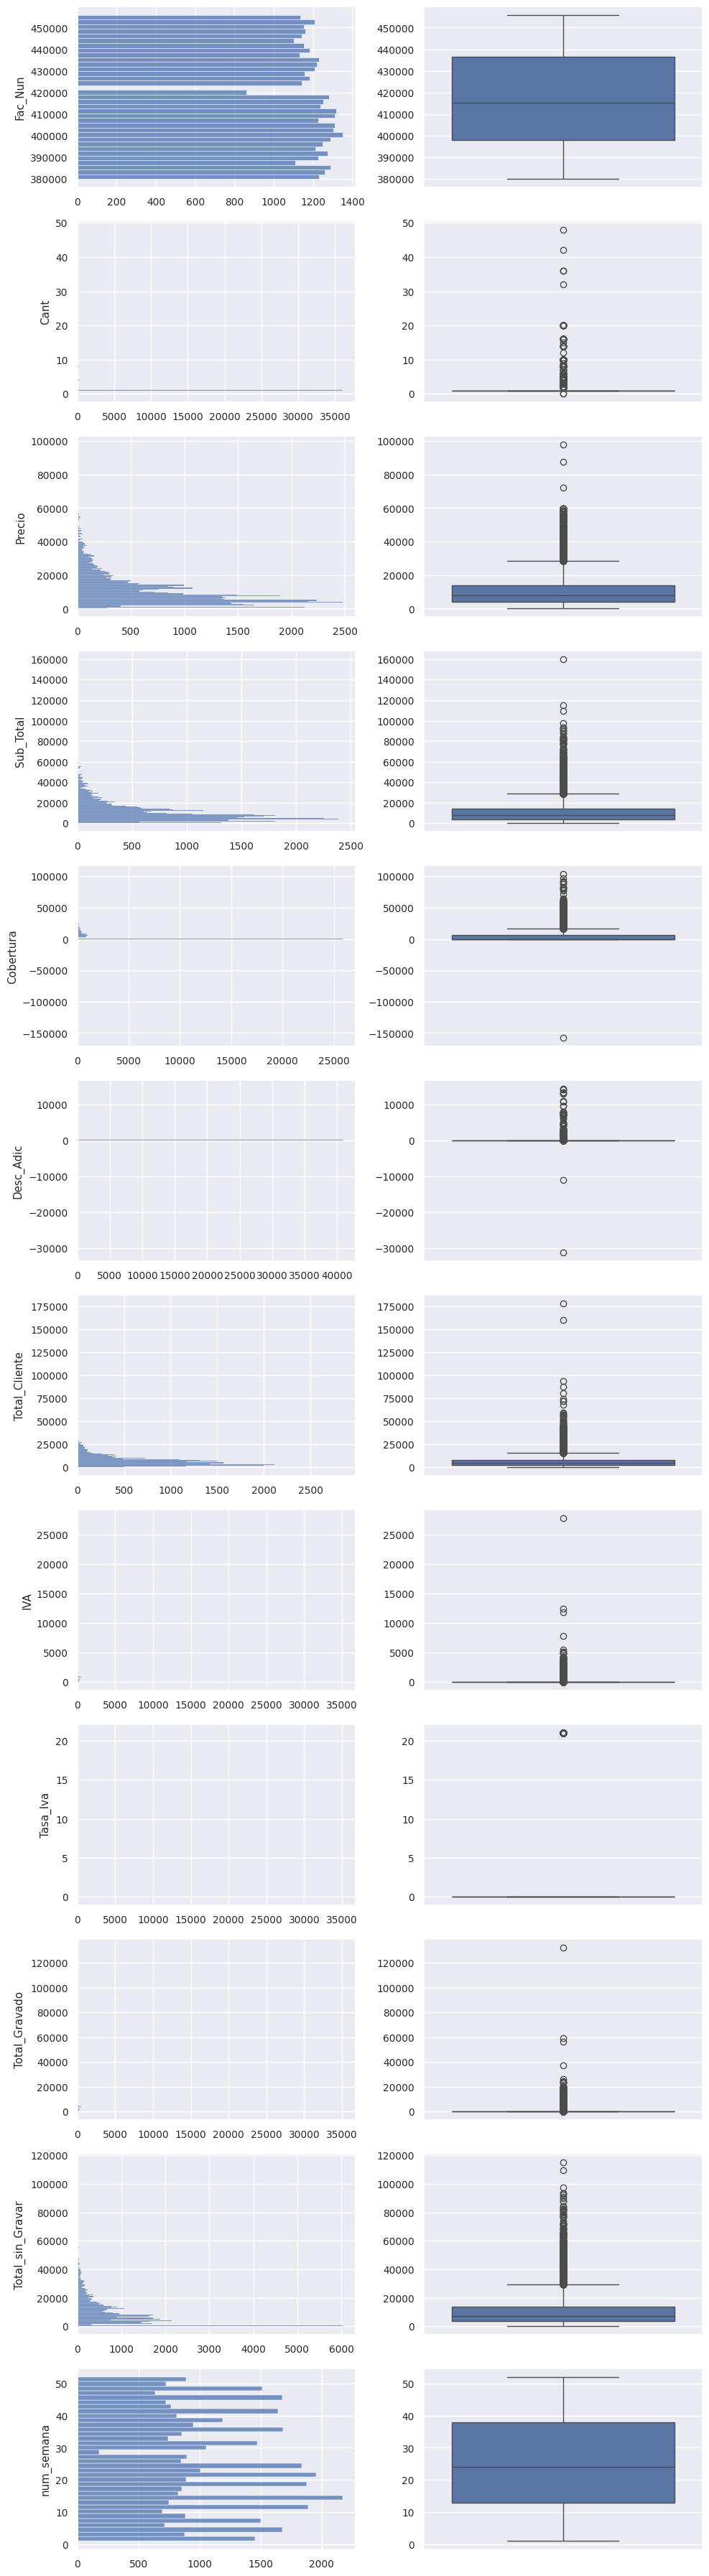

In [240]:
fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

#### Observaciones.

`Fac. Suc.` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Fac. Nun.` - Es el numero de factura, como un id, tampoco nos aporta mucho a lo que buscamos.    
`Cant.` - Aunque la mayoria tienen como valor 1, el resto de outliner parecen ser reales, la conservaremos para tratarla detalladamente mas adelante.  
`Precio` - Es el precio por unidad que tiene un producto  
`Sub. Total` - Es el resultado de multiplicar el precio por cantidad   
`Cobertura` - Es lo que cubre la seguridad social.   
`Ajustes` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Desc. Adic.` - Aunque la mayoria de los valores estan en 0, tiene numeros en negativos y positivos, tambien revisaremos a profundidad.  
`Total. Cliente` -  La mayoria de valores esta entre 0 y 25000, tiene varios outliners que debemos tomar en cuenta.  
`IVA` -  Esta variable va desde el 0 al 160000, tiene sentido ya que sera el iva por producto.  
`Tasa Iva` - esta entre 0, 10% y 21%    
`Total Gravado` -  los valores principalmente estan en 0, pero notamos algunos outliners que revisaremos a detalle  
`Total sin Gravar` -   Los valores estan entre 0 y 60000 aproximadamente, encontramos varios outliners que analizaremos lo que nos dice mas adelante.  

In [241]:
df = df.drop(columns=["Fac. Suc", "Fac. Nun.", "Ajustes"], errors="ignore")

In [242]:
df.columns

Index(['Fecha', 'Fac_Tipo', 'Fac_Nun', 'Cant', 'Precio', 'Producto',
       'Sub_Total', 'Rubro', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA',
       'Tasa_Iva', 'Total_Gravado', 'Total_sin_Gravar', 'num_semana', 'brand',
       'product', 'dose', 'Mes', 'Día', 'form', 'groups'],
      dtype='object')

In [243]:
df[["Producto", "Precio", "Sub_Total", "Cant", "Cobertura", "Desc_Adic", "Tasa_Iva", "IVA","Total_Gravado", "Total_sin_Gravar", "Total_Cliente"]].head(10)

,Producto,Precio,Sub_Total,Cant,Cobertura,Desc_Adic,Tasa_Iva,IVA,Total_Gravado,Total_sin_Gravar,Total_Cliente
8,accesorio (unica),3500.0,7000.0,2,0.0,0.0,21,1214.876033,5785.123967,0.0,7000.0
9,qura plus comp.rec.x 20,3430.0,3430.0,1,0.0,343.0,0,0.000000,0.000000,3430.0,3087.0
13,acc lp gasa esteril no 5 caja 10 x 10,4500.0,4500.0,1,0.0,0.0,21,780.991736,3719.008264,0.0,4500.0
15,acc lp agua oxigenada 10 vol\tx 100 cc,1000.0,1000.0,1,0.0,0.0,21,173.553719,826.446281,0.0,1000.0
16,curitas (unica),800.0,800.0,1,0.0,0.0,0,0.000000,0.000000,800.0,800.0
20,acc lp gasa esteril no 5 caja 10 x 10,4500.0,4500.0,1,0.0,0.0,21,780.991736,3719.008264,0.0,4500.0
22,gen lp ibuprofeno blister 600 mg x 10,3500.0,3500.0,1,0.0,0.0,0,0.000000,0.000000,3500.0,3500.0
31,rhinal gts.x 30 ml,5360.0,5360.0,1,0.0,0.0,0,0.000000,0.000000,5360.0,5360.0
32,sertal compuesto comp.rec.x 20,11200.0,5600.0,10,0.0,0.0,0,0.000000,0.000000,5600.0,5600.0
33,ventolin hfa aer.inh.c/aplic.x200ds.,17470.0,17470.0,1,0.0,0.0,0,0.000000,0.000000,17470.0,17470.0


### 🎯 Nuestros objetivos:

###  Como primer objetivo, nos planteamos una temporalidad de una semana, es decir, predecir el tipo y la cantidad de productos vendidos por semana.
> - Con los datos que tenemos nos parece viable hacer predicciones de ventas de productos. Ajustaremos y limpiaremos el DataSet en una copia para dejar los datos que tenemos hasta aca para otro tipo de predicciones.

In [244]:
df_obj_one = df.copy()

In [245]:
df_obj_one.head(10)

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,...,Total_Gravado,Total_sin_Gravar,num_semana,brand,product,dose,Mes,Día,form,groups
8,2025-01-01 07:46:36,B,379930,2,3500.0,accesorio (unica),7000.0,FARMACIA,0.0,0.0,...,5785.123967,0.0,1,accesorio,accesorio,UNICA,2025-01,1,Otros,Accesorios y Dispositivos Médicos
9,2025-01-02 08:08:38,B,379931,1,3430.0,qura plus comp.rec.x 20,3430.0,FARMACIA,0.0,343.0,...,0.000000,3430.0,1,qura,qura plus,NaN,2025-01,2,Comprimido,Nutrición y Suplementos
13,2025-01-02 08:44:01,B,379935,1,4500.0,acc lp gasa esteril no 5 caja 10 x 10,4500.0,FARMACIA,0.0,0.0,...,3719.008264,0.0,1,acc,acc lp gasa esteril no 5 caja,NaN,2025-01,2,Otros,Material de Curación
15,2025-01-02 08:44:01,B,379935,1,1000.0,acc lp agua oxigenada 10 vol\tx 100 cc,1000.0,FARMACIA,0.0,0.0,...,826.446281,0.0,1,acc,acc lp agua oxigenada 10 vol,NaN,2025-01,2,Otros,Material de Curación
16,2025-01-02 08:44:01,B,379935,1,800.0,curitas (unica),800.0,FARMACIA,0.0,0.0,...,0.000000,800.0,1,curitas,curitas,UNICA,2025-01,2,Otros,Accesorios y Dispositivos Médicos
20,2025-01-02 09:00:10,B,379937,1,4500.0,acc lp gasa esteril no 5 caja 10 x 10,4500.0,FARMACIA,0.0,0.0,...,3719.008264,0.0,1,acc,acc lp gasa esteril no 5 caja,NaN,2025-01,2,Otros,Material de Curación
22,2025-01-02 09:00:10,B,379937,1,3500.0,gen lp ibuprofeno blister 600 mg x 10,3500.0,FARMACIA,0.0,0.0,...,0.000000,3500.0,1,gen,ibuprofeno,600 mg,2025-01,2,Otros,Analgésicos / Antiinflamatorios
31,2025-01-02 09:08:40,B,379941,1,5360.0,rhinal gts.x 30 ml,5360.0,FARMACIA,0.0,0.0,...,0.000000,5360.0,1,rhinal,rhinal gts,NaN,2025-01,2,Otros,Gripe
32,2025-01-02 09:08:40,B,379941,10,11200.0,sertal compuesto comp.rec.x 20,5600.0,FARMACIA,0.0,0.0,...,0.000000,5600.0,1,sertal,propinox + clonixinato de lisina,NaN,2025-01,2,Comprimido,Salud Digestiva
33,2025-01-02 09:08:40,B,379941,1,17470.0,ventolin hfa aer.inh.c/aplic.x200ds.,17470.0,FARMACIA,0.0,0.0,...,0.000000,17470.0,1,ventolin,salbutamol,NaN,2025-01,2,Otros,Salud Respiratoria / Antialérgicos


In [246]:
df.columns

Index(['Fecha', 'Fac_Tipo', 'Fac_Nun', 'Cant', 'Precio', 'Producto',
       'Sub_Total', 'Rubro', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA',
       'Tasa_Iva', 'Total_Gravado', 'Total_sin_Gravar', 'num_semana', 'brand',
       'product', 'dose', 'Mes', 'Día', 'form', 'groups'],
      dtype='object')

In [247]:
cols_drop = ["Sub_Total", "IVA", "Tasa_Iva", "Total_Gravado",
            "Total_sin_Gravar", "Total_Cliente", "Cobertura",
            "Desc_Adic", "Producto", "Fac_Tipo", "Fac_Suc",
            "Precio", "Rubro", "Fecha", "dose","Fac_Nun"]

df_obj_one = df.drop(columns=cols_drop, errors="ignore")

In [248]:
df_obj_one

,Cant,num_semana,brand,product,Mes,Día,form,groups
8,2,1,accesorio,accesorio,2025-01,1,Otros,Accesorios y Dispositivos Médicos
9,1,1,qura,qura plus,2025-01,2,Comprimido,Nutrición y Suplementos
13,1,1,acc,acc lp gasa esteril no 5 caja,2025-01,2,Otros,Material de Curación
15,1,1,acc,acc lp agua oxigenada 10 vol,2025-01,2,Otros,Material de Curación
16,1,1,curitas,curitas,2025-01,2,Otros,Accesorios y Dispositivos Médicos
...,...,...,...,...,...,...,...,...
117281,2,52,levotiroxina,levotiroxina,2025-12,23,Comprimido,Diabetes y Endocrino
117286,1,52,ultra,ultra corega crema sin sabor pomo,2025-12,23,Otros,Higiene y Cuidado Personal
117288,8,52,mylanta,mylanta extra,2025-12,23,Comprimido,Salud Digestiva
117289,1,52,colgate,colgate,2025-12,23,Otros,Higiene y Cuidado Personal


> - Para el modelo necesitamos visualizar de la lista de productos semanal cuales fueron las ventas, pero si no hubo sucede que no podemos visualizarlo. para eso crearemos un df que rellenaremos con los datos del `df_obj_one` que ya tenemos.

In [249]:
products = df_obj_one["product"].dropna().unique()
weeks = df_obj_one["num_semana"].dropna().unique()
base = pd.MultiIndex.from_product([products, weeks], names=["product", "num_semana"]).to_frame(index=False)
base["cantidad"] = 0

In [250]:
base

,product,num_semana,cantidad
0,accesorio,1,0
1,accesorio,2,0
2,accesorio,3,0
3,accesorio,4,0
4,accesorio,5,0
...,...,...,...
6829,vick forte,48,0
6830,vick forte,49,0
6831,vick forte,50,0
6832,vick forte,51,0


In [251]:
df_obj_one = (df_obj_one.groupby(["num_semana","product"], as_index=False)["Cant"].sum().rename(columns={"Cant":"y"}))

In [252]:
base = (base
               .drop(columns=["cantidad"], errors="ignore")   
               .merge(df_obj_one, on=["product", "num_semana"], how="left"))

base["y"] = base["y"].fillna(0).astype(int)

base.head()

,product,num_semana,y
0,accesorio,1,5
1,accesorio,2,11
2,accesorio,3,20
3,accesorio,4,5
4,accesorio,5,3


In [253]:
base.loc[base["num_semana"] == 1]

,product,num_semana,y
0,accesorio,1,5
51,qura plus,1,1
102,acc lp gasa esteril no 5 caja,1,5
153,acc lp agua oxigenada 10 vol,1,3
204,curitas,1,2
...,...,...,...
6579,acc lp alcohol puro,1,0
6630,treg,1,0
6681,next forte,1,0
6732,vivita forte antigripal pouch,1,0


In [254]:
base = base.sort_values(["product", "num_semana"]).reset_index(drop=True)


for l in range(1, 9):
    base[f"y_lag{l}"] = base.groupby("product")["y"].shift(l)

lag_cols = [f"y_lag{l}" for l in range(1, 9)]
past_mean = (base.groupby("product")["y"]
               .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
               .reset_index(level=0, drop=True))
for c in lag_cols:
    base[c] = base[c].fillna(past_mean)
base[lag_cols] = base[lag_cols].fillna(0)
base[lag_cols] = np.ceil(base[lag_cols]).astype(int)

In [255]:
base.loc[base["product"] == "acc lp agua oxigenada 10 vol"].head(10)

,product,num_semana,y,y_lag1,y_lag2,y_lag3,y_lag4,y_lag5,y_lag6,y_lag7,y_lag8
0,acc lp agua oxigenada 10 vol,1,3,0,0,0,0,0,0,0,0
1,acc lp agua oxigenada 10 vol,2,8,3,3,3,3,3,3,3,3
2,acc lp agua oxigenada 10 vol,3,17,8,3,6,6,6,6,6,6
3,acc lp agua oxigenada 10 vol,4,9,17,8,3,10,10,10,10,10
4,acc lp agua oxigenada 10 vol,5,10,9,17,8,3,10,10,10,10
5,acc lp agua oxigenada 10 vol,6,7,10,9,17,8,3,10,10,10
6,acc lp agua oxigenada 10 vol,7,5,7,10,9,17,8,3,9,9
7,acc lp agua oxigenada 10 vol,8,10,5,7,10,9,17,8,3,9
8,acc lp agua oxigenada 10 vol,9,9,10,5,7,10,9,17,8,3
9,acc lp agua oxigenada 10 vol,10,9,9,10,5,7,10,9,17,8


In [256]:
base.to_csv("../data/processed/df_base_EDA", index=False)